# Download the dataset

In [7]:
# If the link is to a Drive folder, use gdown to download all files in the folder and unzip any zips.
import subprocess, sys, os
from pathlib import Path


def download_drive_folder(url, dest='data', force=False):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    try:
        import gdown
    except Exception:
        print('gdown not found, installing...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gdown'])
        import gdown

    expected_dirs = {'HailuoAI', 'KlingAI', 'DaVinci'}
    expected_files = {'gen_metadata.csv', 'metadata.csv', 'prompts.docx', 'negative_prompts.docx'}
    has_expected_dirs = any((dest / name).exists() for name in expected_dirs)
    has_expected_files = any((dest / name).exists() for name in expected_files)

    if (has_expected_dirs and has_expected_files) and not force:
        print(f'Existing dataset detected in {dest}; skipping download.')
        return dest

    print('Scanning remote folder and local cache at', dest)

    # Build the remote manifest first, then only download files that are missing locally.
    remote_items = gdown.download_folder(
        url,
        output=str(dest),
        quiet=True,
        use_cookies=False,
        skip_download=True,
    )

    downloaded = 0
    skipped = 0
    failed = 0
    for item in remote_items:
        local_path = Path(item.local_path)
        if local_path.exists() and local_path.is_file() and local_path.stat().st_size > 0:
            skipped += 1
            continue

        if item.id is None:
            local_path.mkdir(parents=True, exist_ok=True)
            continue

        local_path.parent.mkdir(parents=True, exist_ok=True)
        download_output = str(local_path) if local_path.suffix else str(local_path.parent) + os.sep
        print(f'Downloading missing file: {item.path}')
        try:
            gdown.download(
                url='https://drive.google.com/uc?id=' + item.id,
                output=download_output,
                quiet=False,
                use_cookies=False,
                resume=True,
            )
            downloaded += 1
        except Exception as e:
            failed += 1
            print(f'Skipping unavailable remote file {item.path}: {e}')

    print(f'Download check finished: {downloaded} downloaded, {skipped} skipped, {failed} unavailable')

    # Unzip any zip files found under dest
    import zipfile
    for z in dest.rglob('*.zip'):
        try:
            with zipfile.ZipFile(z, 'r') as zz:
                zz.extractall(z.parent)
            print(f'Unzipped {z} -> {z.parent}')
        except Exception as e:
            print(f'Failed to unzip {z}: {e}')
    return dest


# Example: replace with your folder URL and run this cell to download everything into ./data
folder_url = 'https://drive.google.com/drive/folders/1QiSx21F0Z12Bqbdkyr8AdOwrOUy4bD3T?usp=sharing'
download_drive_folder(folder_url, dest='data')


Existing dataset detected in data; skipping download.


PosixPath('data')

In [ ]:
print("\n" + "="*80)
print("DATASET STATISTICS AND ANALYSIS")
print("="*80)

# Basic dataset statistics
total_images = len(base_samples)
num_applications = len(label_names)
train_size = len(train_idx)
val_size = len(val_idx)
test_size = len(test_idx)

print(f"\n📊 DATASET OVERVIEW")
print(f"Total images: {total_images}")
print(f"Number of applications (classes): {num_applications}")
print(f"Train/Val/Test split: {train_size}/{val_size}/{test_size}")
print(f"Train ratio: {train_size/total_images:.1%} | Val ratio: {val_size/total_images:.1%} | Test ratio: {test_size/total_images:.1%}")

# Per-application statistics
print(f"\n📋 PER-APPLICATION STATISTICS")
app_stats = {}

for label_name in label_names:
    total_per_app = 0
    train_per_app = 0
    val_per_app = 0
    test_per_app = 0
    
    for i, sample in enumerate(base_samples):
        if sample['label'] == label_name:
            total_per_app += 1
            if i in train_idx:
                train_per_app += 1
            elif i in val_idx:
                val_per_app += 1
            elif i in test_idx:
                test_per_app += 1
    
    app_stats[label_name] = {
        'total': total_per_app,
        'train': train_per_app,
        'val': val_per_app,
        'test': test_per_app,
    }
    
    print(f"{label_name:.<20} Total: {total_per_app:>2}  Train: {train_per_app:>2}  Val: {val_per_app:>2}  Test: {test_per_app:>2}")

# Class balance analysis
print(f"\n⚖️ CLASS BALANCE ANALYSIS")
total_per_app_vals = [app_stats[app]['total'] for app in label_names]
non_zero_counts = [x for x in total_per_app_vals if x > 0]

if non_zero_counts:
    min_samples = min(non_zero_counts)
    max_samples = max(non_zero_counts)
    mean_samples = sum(non_zero_counts) / len(non_zero_counts)
    std_samples = (sum((x - mean_samples)**2 for x in non_zero_counts) / len(non_zero_counts))**0.5
    
    print(f"Samples per class - Min: {min_samples}, Max: {max_samples}, Mean: {mean_samples:.1f}, Std: {std_samples:.2f}")
    if min_samples > 0:
        print(f"Imbalance ratio: {max_samples / min_samples:.2f}x (max/min)")

# Image resolution statistics
print(f"\n IMAGE RESOLUTION STATISTICS")
resolutions = {}
for label_name in label_names:
    for sample in base_samples:
        if sample['label'] == label_name:
            img_path = sample['path']
            try:
                from PIL import Image
                img = Image.open(img_path)
                resolutions[label_name] = img.size
            except:
                resolutions[label_name] = None
            break

for label_name in label_names:
    if resolutions.get(label_name):
        w, h = resolutions[label_name]
        print(f"{label_name:.<20} {w}×{h}")

# Stratification check
print(f"\n STRATIFICATION VERIFICATION (Train split class distribution)")
for label_name in label_names:
    count_in_train = sum(1 for i in train_idx if base_samples[i]['label'] == label_name)
    if count_in_train > 0:
        train_percentage = count_in_train / train_size * 100
        print(f"  {label_name:.<20} {count_in_train:>2} ({train_percentage:>5.1f}%)")

print(f"\n Dataset statistics computed successfully")



DATASET STATISTICS AND ANALYSIS

📊 DATASET OVERVIEW
Total images: 323
Number of applications (classes): 8
Train/Val/Test split: 193/65/65
Train ratio: 59.8% | Val ratio: 20.1% | Test ratio: 20.1%

📋 PER-APPLICATION STATISTICS
DaVinci............. Total: 32  Train: 19  Val:  6  Test:  7
Freepik............. Total: 51  Train: 31  Val: 10  Test: 10
HailuoAI............ Total: 32  Train: 19  Val:  7  Test:  6
KlingAI............. Total: 49  Train: 29  Val: 10  Test: 10
Leonardo.Ai......... Total: 64  Train: 38  Val: 13  Test: 13
PhotoFlux........... Total: 16  Train: 10  Val:  3  Test:  3
PixVerse............ Total: 64  Train: 38  Val: 13  Test: 13
SeaArt.............. Total: 15  Train:  9  Val:  3  Test:  3

⚖️ CLASS BALANCE ANALYSIS
Samples per class - Min: 15, Max: 64, Mean: 40.4, Std: 18.31
Imbalance ratio: 4.27x (max/min)

📐 IMAGE RESOLUTION STATISTICS
DaVinci............. 1024×1024
Freepik............. 1024×1024
HailuoAI............ 2048×2048
KlingAI............. 720×1280
Leonardo.A

In [15]:
from pathlib import Path
import pandas as pd
from PIL import Image

def normalize_label_text(value):
    parts = value.split() if isinstance(value, str) else []
    return parts[-1] if len(parts) > 1 else value

def _load_metadata_table(metadata_path):
    metadata_path = Path(metadata_path)
    suffix = metadata_path.suffix.lower()
    if suffix in {'.xls', '.xlsx', '.xlsm', '.xlsb'}:
        metadata = pd.read_excel(metadata_path)
    else:
        try:
            metadata = pd.read_csv(metadata_path)
        except Exception:
            metadata = pd.read_excel(metadata_path)
    if 'App' in metadata.columns and 'label' not in metadata.columns:
        metadata = metadata.rename(columns={'App': 'label'})
    if 'label' in metadata.columns:
        metadata['label'] = metadata['label'].apply(lambda value: normalize_label_text(value) if isinstance(value, str) else value)
    return metadata

class FolderImageMetadataDataset:
    def __init__(self, root_dir='data', metadata_path=None, metadata_row_base=1, image_extensions=('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
        self.root_dir = Path(root_dir)
        self.metadata_path = Path(metadata_path) if metadata_path else self._default_metadata_path()
        self.metadata = _load_metadata_table(self.metadata_path)
        self.metadata_row_base = metadata_row_base
        self.image_extensions = tuple(ext.lower() for ext in image_extensions)
        self.samples = self._build_samples()

    def _default_metadata_path(self):
        for candidate in [self.root_dir / 'metadata.csv', self.root_dir / 'gen_metadata_2.csv']:
            if candidate.exists():
                return candidate
        raise FileNotFoundError('Could not find metadata.csv or gen_metadata.csv in the root directory.')

    def _row_from_index(self, index_value):
        row_index = int(index_value) - self.metadata_row_base
        if row_index < 0 or row_index >= len(self.metadata):
            raise IndexError(f'Metadata row {index_value} is out of range for {self.metadata_path}')
        return self.metadata.iloc[row_index].to_dict()

    def _build_samples(self):
        samples = []
        for class_dir in sorted([p for p in self.root_dir.iterdir() if p.is_dir()]):
            if class_dir.name.startswith('.') or class_dir.name in {'__MACOSX'}:
                continue
            normalized_class_name = normalize_label_text(class_dir.name)
            for group_dir in sorted([p for p in class_dir.iterdir() if p.is_dir()]):
                if not group_dir.name.isdigit():
                    continue
                metadata_row = self._row_from_index(group_dir.name)
                for image_path in sorted(group_dir.iterdir()):
                    if image_path.is_file() and image_path.suffix.lower() in self.image_extensions:
                        samples.append({
                            'image_path': image_path,
                            'class_name': normalized_class_name,
                            'group_id': int(group_dir.name),
                            'metadata': metadata_row,
                        })
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = Image.open(sample['image_path']).convert('RGB')
        return {
            'image': image,
            'image_path': str(sample['image_path']),
            'class_name': sample['class_name'],
            'group_id': sample['group_id'],
            'metadata': sample['metadata'],
        }

dataset = FolderImageMetadataDataset(root_dir='data', metadata_row_base=1)
sample = dataset[0]
print('Loaded samples:', len(dataset))
print(sample['image_path'])
print('label:', sample['metadata'].get('label'))
print(sample['metadata'])

Loaded samples: 323
data/AI Image Generator or PhotoFlux/66/photoflux_batch_1777992749755.png
label: PhotoFlux
{'Sl no': 66, 'Reference Image': 'Zinedine_Zidane_0001.jpg', 'Dataset': 1, 'label': 'PhotoFlux', 'Face Reference': nan, 'Subject Refernce': nan, 'Prompt': 1, 'Negative Prompt': nan, 'Generations': 1, 'model': 'Undisclosed', 'Output dir': 66, 'Credits': nan}


In [16]:
# Refresh the shared label variables so all downstream experiments use the normalized last-word labels.
base_samples = scan_app_images('data')
label_names = sorted({sample['label'] for sample in base_samples})
label_to_idx = {label: idx for idx, label in enumerate(label_names)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
indices = list(range(len(base_samples)))
labels = [label_to_idx[sample['label']] for sample in base_samples]

train_idx, temp_idx = train_test_split(indices, test_size=0.4, random_state=42, stratify=labels)
train_labels = [labels[i] for i in train_idx]
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=temp_labels)

print('Normalized labels:', label_names)
print('Samples loaded for downstream experiments:', len(base_samples))

Normalized labels: ['DaVinci', 'Freepik', 'HailuoAI', 'KlingAI', 'Leonardo.Ai', 'PhotoFlux', 'PixVerse', 'SeaArt']
Samples loaded for downstream experiments: 323


## Baseline 1 : Non-visual - Use image metadata

In [12]:
from pathlib import Path
import math
import pandas as pd
from PIL import Image, ExifTags

try:
    import numpy as np
except Exception:
    np = None

try:
    from iptcinfo3 import IPTCInfo
except Exception:
    IPTCInfo = None

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


def _exif_text_value(exif, tag_name):
    for tag_id, value in exif.items():
        if ExifTags.TAGS.get(tag_id) == tag_name:
            if isinstance(value, bytes):
                try:
                    return value.decode('utf-8', errors='ignore')
                except Exception:
                    return str(value)
            return value
    return None


def _extract_non_visual_features(image_path):
    image_path = Path(image_path)
    with Image.open(image_path) as image:
        width, height = image.size
        exif = image.getexif() or {}
        creator = _exif_text_value(exif, 'Artist') or _exif_text_value(exif, 'ImageDescription')
        software = _exif_text_value(exif, 'Software')
        color_space_code = exif.get(40961)
        color_space = {
            1: 'sRGB',
            2: 'AdobeRGB',
            65535: 'Uncalibrated',
        }.get(color_space_code, str(color_space_code) if color_space_code is not None else None)

    if (creator is None or creator == '') and IPTCInfo is not None and image_path.suffix.lower() in {'.jpg', '.jpeg'}:
        try:
            iptc = IPTCInfo(str(image_path), force=True)
            creator = iptc.get('by-line') or iptc.get('creator') or iptc.get('credit')
            if isinstance(creator, bytes):
                creator = creator.decode('utf-8', errors='ignore')
        except Exception:
            pass

    file_size_kb = image_path.stat().st_size / 1024.0
    pixels = width * height
    aspect_ratio = width / height if height else None
    megapixels = pixels / 1_000_000.0
    resolution_bucket = (
        'low'
        if pixels < 500_000
        else 'medium'
        if pixels < 2_000_000
        else 'high'
    )
    size_density = file_size_kb / megapixels if megapixels else None
    file_size_band = (
        'small'
        if size_density is not None and size_density < 150
        else 'medium'
        if size_density is not None and size_density < 350
        else 'large'
    )

    return {
        'creator': creator,
        'software': software,
        'color_space': color_space,
        'width': width,
        'height': height,
        'aspect_ratio': aspect_ratio,
        'pixels': pixels,
        'file_size_kb': file_size_kb,
        'megapixels': megapixels,
        'resolution_bucket': resolution_bucket,
        'file_size_band': file_size_band,
    }


feature_rows = []
for sample in dataset.samples:
    features = _extract_non_visual_features(sample['image_path'])
    features['label'] = sample['metadata'].get('label', sample['class_name'])
    features['image_path'] = str(sample['image_path'])
    feature_rows.append(features)

baseline_df = pd.DataFrame(feature_rows).dropna(subset=['label'])
print('Feature table shape:', baseline_df.shape)
print(baseline_df[['label', 'creator', 'software', 'color_space', 'resolution_bucket', 'file_size_band']].head())

X = baseline_df.drop(columns=['label', 'image_path'])
y = baseline_df['label']

categorical_features = ['creator', 'software', 'color_space', 'resolution_bucket', 'file_size_band']
numeric_features = ['width', 'height', 'aspect_ratio', 'pixels', 'file_size_kb', 'megapixels']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
        ('num', SimpleImputer(strategy='median'), numeric_features),
    ]
)

classifier = Pipeline([
    ('features', preprocessor),
    ('model', LogisticRegression(max_iter=1000)),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y if y.nunique() > 1 else None
)

classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print('Baseline accuracy:', round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))

Feature table shape: (323, 13)
       label creator software color_space resolution_bucket file_size_band
0  PhotoFlux    None     None        None            medium          large
1  PhotoFlux    None     None        None            medium          large
2  PhotoFlux    None     None        None            medium          large
3  PhotoFlux    None     None        None            medium          large
4  PhotoFlux    None     None        None            medium          large
Baseline accuracy: 0.321
              precision    recall  f1-score   support

     DaVinci       0.30      0.38      0.33         8
     Freepik       0.35      0.46      0.40        13
    HailuoAI       0.33      0.12      0.18         8
     KlingAI       0.00      0.00      0.00        12
 Leonardo.Ai       0.23      0.31      0.26        16
   PhotoFlux       0.00      0.00      0.00         4
    PixVerse       0.55      0.69      0.61        16
      SeaArt       0.00      0.00      0.00         4

    ac

/home/mal-01/mahim/p2/.p2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/mal-01/mahim/p2/.p2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mal-01/mahim/p2/.p2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defin

Epoch 1/5 | train loss 1.9594 acc 0.2021 | val loss 1.7212 acc 0.3846
Epoch 2/5 | train loss 1.4315 acc 0.4456 | val loss 1.3680 acc 0.4923
Epoch 3/5 | train loss 0.8823 acc 0.6943 | val loss 1.0914 acc 0.6000
Epoch 4/5 | train loss 0.5376 acc 0.8394 | val loss 0.9915 acc 0.5231
Epoch 5/5 | train loss 0.2959 acc 0.9326 | val loss 1.1186 acc 0.6615
Clean test accuracy: 0.6308
              precision    recall  f1-score   support

     DaVinci       0.60      0.43      0.50         7
     Freepik       0.67      0.20      0.31        10
    HailuoAI       0.43      0.50      0.46         6
     KlingAI       1.00      0.90      0.95        10
 Leonardo.Ai       0.45      0.77      0.57        13
   PhotoFlux       1.00      1.00      1.00         3
    PixVerse       0.73      0.85      0.79        13
      SeaArt       0.00      0.00      0.00         3

    accuracy                           0.63        65
   macro avg       0.61      0.58      0.57        65
weighted avg       0.64   

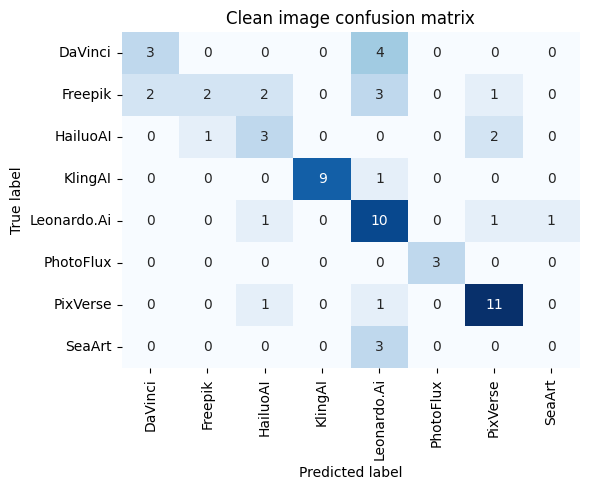

Robustness results:
        corruption  accuracy
0         jpeg_q40  0.400000
1        blur_r1.2  0.630769
2  resize_384->512  0.569231


In [13]:
import io
from pathlib import Path
from PIL import Image, ImageFilter

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

try:
    import seaborn as sns
except Exception:
    sns = None


def normalize_label_text(value):
    parts = value.split() if isinstance(value, str) else []
    return parts[-1] if len(parts) > 1 else value


def scan_app_images(root_dir='data'):
    root_dir = Path(root_dir)
    samples = []
    for class_dir in sorted([p for p in root_dir.iterdir() if p.is_dir()]):
        if class_dir.name.startswith('.') or class_dir.name in {'__MACOSX'}:
            continue
        label_name = normalize_label_text(class_dir.name)
        for group_dir in sorted([p for p in class_dir.iterdir() if p.is_dir()]):
            if not group_dir.name.isdigit():
                continue
            for image_path in sorted(group_dir.iterdir()):
                if image_path.is_file() and image_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}:
                    samples.append({'path': image_path, 'label': label_name})
    return samples


class AppImageDataset(Dataset):
    def __init__(self, samples, label_to_idx, transform=None):
        self.samples = samples
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        with Image.open(sample['path']) as image:
            image = image.convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, self.label_to_idx[sample['label']], str(sample['path'])


def jpeg_compress(image, quality=40):
    buffer = io.BytesIO()
    image.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert('RGB')


def small_blur(image, radius=1.2):
    return image.filter(ImageFilter.GaussianBlur(radius=radius))


def resize_roundtrip(image, downscale=384, target=512):
    image = image.resize((downscale, downscale), Image.BICUBIC)
    return image.resize((target, target), Image.BICUBIC)


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
BASE_SIZE = 512
USE_RANDOM_PATCHES = False
PATCH_SIZE = 256
BATCH_SIZE = 2
EPOCHS = 5
LR = 1e-4

base_samples = scan_app_images('data')
label_names = sorted({sample['label'] for sample in base_samples})
label_to_idx = {label: idx for idx, label in enumerate(label_names)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
indices = list(range(len(base_samples)))
labels = [label_to_idx[sample['label']] for sample in base_samples]

train_idx, temp_idx = train_test_split(indices, test_size=0.4, random_state=42, stratify=labels)
train_labels = [labels[i] for i in train_idx]
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=temp_labels)

if USE_RANDOM_PATCHES:
    train_transform = transforms.Compose([
        transforms.Resize((BASE_SIZE, BASE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(PATCH_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
else:
    train_transform = transforms.Compose([
        transforms.Resize((BASE_SIZE, BASE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomResizedCrop(BASE_SIZE, scale=(0.9, 1.0), ratio=(0.95, 1.05)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

clean_eval_transform = transforms.Compose([
    transforms.Resize((BASE_SIZE, BASE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def make_eval_transform(corruption=None):
    def _transform(image):
        if corruption is not None:
            image = corruption(image)
        return clean_eval_transform(image)
    return _transform


train_dataset = AppImageDataset([base_samples[i] for i in train_idx], label_to_idx, transform=train_transform)
val_dataset = AppImageDataset([base_samples[i] for i in val_idx], label_to_idx, transform=clean_eval_transform)
test_dataset = AppImageDataset([base_samples[i] for i in test_idx], label_to_idx, transform=clean_eval_transform)

pin_memory = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)

for param in model.parameters():
    param.requires_grad = False

if hasattr(model, 'features'):
    for module in list(model.features.children())[-2:]:
        for param in module.parameters():
            param.requires_grad = True

if hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
    classifier_in = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(classifier_in, len(label_names))
    for param in model.classifier.parameters():
        param.requires_grad = True
else:
    raise AttributeError('Expected a ConvNeXt classifier head.')

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=1e-4)


def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    all_true = []
    all_pred = []
    for images, targets, _ in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, targets)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        all_true.extend(targets.detach().cpu().tolist())
        all_pred.extend(preds.detach().cpu().tolist())
    avg_loss = total_loss / max(len(loader.dataset), 1)
    avg_acc = accuracy_score(all_true, all_pred) if all_true else 0.0
    return avg_loss, avg_acc


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(val_loader, training=False)
    print(f'Epoch {epoch}/{EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}')


def evaluate(loader):
    model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for images, targets, _ in loader:
            images = images.to(device, non_blocking=True)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().tolist()
            all_pred.extend(preds)
            all_true.extend(targets.tolist())
    acc = accuracy_score(all_true, all_pred) if all_true else 0.0
    return all_true, all_pred, acc


clean_true, clean_pred, clean_acc = evaluate(test_loader)
print('Clean test accuracy:', round(clean_acc, 4))
print(classification_report(clean_true, clean_pred, target_names=label_names, zero_division=0))

cm = confusion_matrix(clean_true, clean_pred, labels=list(range(len(label_names))))
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
print('Confusion matrix (clean):')
print(cm_df)

plt.figure(figsize=(6, 5))
if sns is not None:
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
else:
    plt.imshow(cm_df.values, cmap='Blues')
    plt.xticks(range(len(label_names)), label_names, rotation=45, ha='right')
    plt.yticks(range(len(label_names)), label_names)
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            plt.text(j, i, cm_df.iloc[i, j], ha='center', va='center', color='black')
plt.title('Clean image confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

corruptions = {
    'jpeg_q40': lambda image: jpeg_compress(image, quality=40),
    'blur_r1.2': lambda image: small_blur(image, radius=1.2),
    'resize_384->512': lambda image: resize_roundtrip(image, downscale=384, target=512),
}

robustness_rows = []
for name, corruption in corruptions.items():
    corrupted_dataset = AppImageDataset([base_samples[i] for i in test_idx], label_to_idx, transform=make_eval_transform(corruption))
    corrupted_loader = DataLoader(corrupted_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)
    _, _, corrupted_acc = evaluate(corrupted_loader)
    robustness_rows.append({'corruption': name, 'accuracy': corrupted_acc})

robustness_df = pd.DataFrame(robustness_rows)
print('Robustness results:')
print(robustness_df)


## Baseline 2 : Use only image features with pretrained transformer based classifiers

PCA explained variance ratio: [np.float32(0.1509), np.float32(0.1078)]


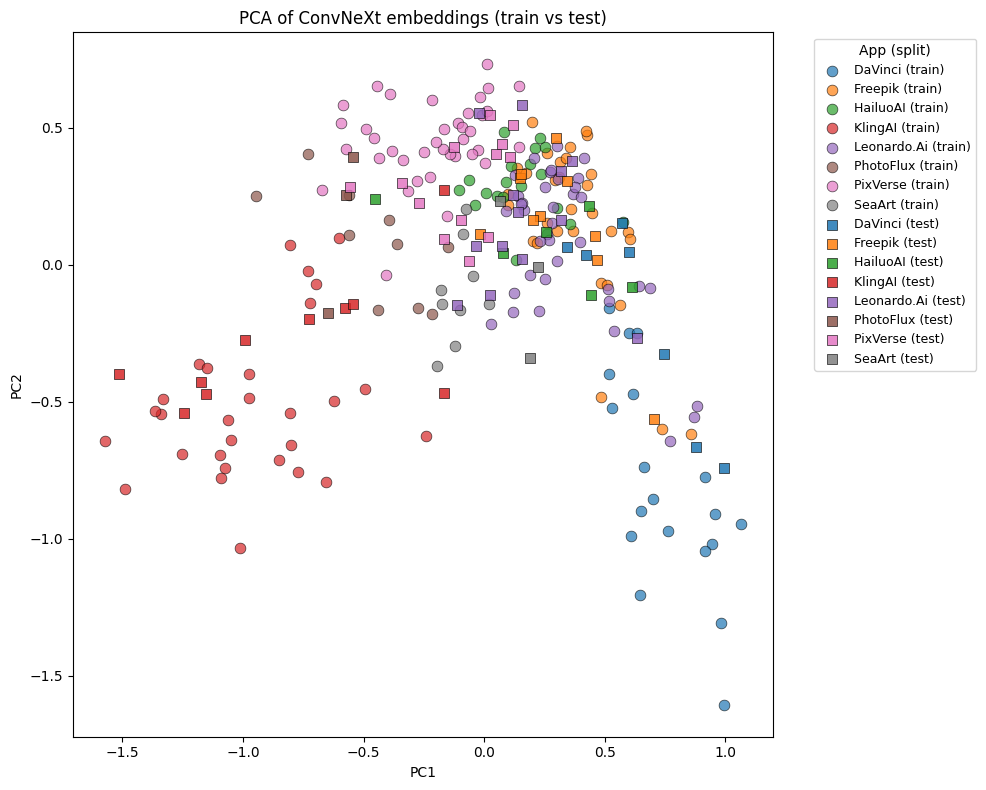

In [10]:
from sklearn.decomposition import PCA


def _embedding_extractor(batch):
    with torch.no_grad():
        features = model.features(batch)
        features = model.avgpool(features)
        features = torch.flatten(features, 1)
    return features


def collect_embeddings(dataset_indices, split_name):
    eval_dataset = AppImageDataset([base_samples[i] for i in dataset_indices], label_to_idx, transform=clean_eval_transform)
    eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)
    all_embeddings = []
    all_labels = []
    all_paths = []
    model.eval()
    with torch.no_grad():
        for images, targets, paths in eval_loader:
            images = images.to(device, non_blocking=True)
            embeddings = _embedding_extractor(images).cpu().numpy()
            all_embeddings.append(embeddings)
            all_labels.extend(targets.cpu().tolist())
            all_paths.extend(paths)
    if all_embeddings:
        all_embeddings = np.concatenate(all_embeddings, axis=0)
    else:
        all_embeddings = np.empty((0, 0))
    return all_embeddings, np.array(all_labels), all_paths


train_embeddings, train_embedding_labels, train_paths = collect_embeddings(train_idx, 'train')
test_embeddings, test_embedding_labels, test_paths = collect_embeddings(test_idx, 'test')

pca = PCA(n_components=2, random_state=42)
train_pca = pca.fit_transform(train_embeddings)
test_pca = pca.transform(test_embeddings)

print('PCA explained variance ratio:', [round(v, 4) for v in pca.explained_variance_ratio_])

train_pca_df = pd.DataFrame({
    'pc1': train_pca[:, 0],
    'pc2': train_pca[:, 1],
    'label': [idx_to_label[idx] for idx in train_embedding_labels],
    'split': 'train',
})

test_pca_df = pd.DataFrame({
    'pc1': test_pca[:, 0],
    'pc2': test_pca[:, 1],
    'label': [idx_to_label[idx] for idx in test_embedding_labels],
    'split': 'test',
})

pca_df = pd.concat([train_pca_df, test_pca_df], ignore_index=True)

plt.figure(figsize=(10, 8))
markers = {'train': 'o', 'test': 's'}
colors = {label_name: f'C{i}' for i, label_name in enumerate(label_names)}

for split in ['train', 'test']:
    for label_name in label_names:
        subset = pca_df[(pca_df['label'] == label_name) & (pca_df['split'] == split)]
        if len(subset) > 0:
            marker = markers[split]
            color = colors[label_name]
            alpha = 0.7 if split == 'train' else 0.85
            label = f'{label_name} ({split})'
            plt.scatter(subset['pc1'], subset['pc2'], s=60, alpha=alpha, marker=marker, color=color, label=label, edgecolors='black', linewidth=0.5)

plt.title('PCA of ConvNeXt embeddings (train vs test)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='App (split)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()



=== EfficientNet-B0 ===
EfficientNet-B0 Epoch 1/5 | train loss 2.0110 acc 0.1762 | val loss 1.9658 acc 0.2615
EfficientNet-B0 Epoch 2/5 | train loss 1.9030 acc 0.3161 | val loss 1.8731 acc 0.3538
EfficientNet-B0 Epoch 3/5 | train loss 1.8237 acc 0.3057 | val loss 1.8495 acc 0.3538
EfficientNet-B0 Epoch 4/5 | train loss 1.7932 acc 0.3420 | val loss 1.7502 acc 0.4615
EfficientNet-B0 Epoch 5/5 | train loss 1.7115 acc 0.3575 | val loss 1.6921 acc 0.3846
EfficientNet-B0 Test accuracy: 0.4
              precision    recall  f1-score   support

     DaVinci       0.80      0.57      0.67         7
     Freepik       0.17      0.10      0.12        10
    HailuoAI       0.00      0.00      0.00         6
     KlingAI       0.86      0.60      0.71        10
 Leonardo.Ai       0.22      0.15      0.18        13
   PhotoFlux       0.00      0.00      0.00         3
    PixVerse       0.34      1.00      0.51        13
      SeaArt       0.00      0.00      0.00         3

    accuracy          

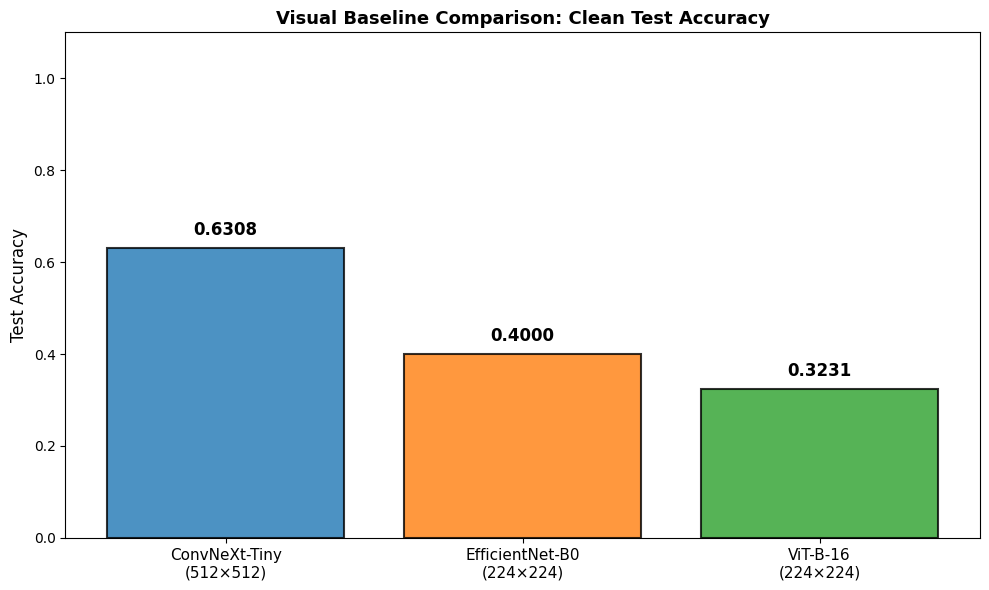

In [11]:
import io
from pathlib import Path
from PIL import Image, ImageFilter

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights, vit_b_16, ViT_B_16_Weights, convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

try:
    import seaborn as sns
except Exception:
    sns = None


def train_and_evaluate_model(model_name, model, device, train_loader, val_loader, test_loader, label_names, epochs=3, lr=1e-4):
    """Train and evaluate a model, return metrics."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=1e-4)
    
    def run_epoch(loader, training=True):
        if training:
            model.train()
        else:
            model.eval()
        total_loss = 0.0
        all_true = []
        all_pred = []
        for images, targets, _ in loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            with torch.set_grad_enabled(training):
                logits = model(images)
                loss = criterion(logits, targets)
                if training:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            all_true.extend(targets.detach().cpu().tolist())
            all_pred.extend(preds.detach().cpu().tolist())
        avg_loss = total_loss / max(len(loader.dataset), 1)
        avg_acc = accuracy_score(all_true, all_pred) if all_true else 0.0
        return avg_loss, avg_acc
    
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(train_loader, training=True)
        val_loss, val_acc = run_epoch(val_loader, training=False)
        print(f'{model_name} Epoch {epoch}/{epochs} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}')
    
    model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for images, targets, _ in test_loader:
            images = images.to(device, non_blocking=True)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().tolist()
            all_pred.extend(preds)
            all_true.extend(targets.tolist())
    
    test_acc = accuracy_score(all_true, all_pred) if all_true else 0.0
    return test_acc, all_true, all_pred


# Create data loaders for different input sizes
def make_loaders_with_size(input_size=512):
    """Create train/val/test loaders for a given input size."""
    train_transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomResizedCrop(input_size, scale=(0.9, 1.0), ratio=(0.95, 1.05)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    
    eval_transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    
    train_dataset = AppImageDataset([base_samples[i] for i in train_idx], label_to_idx, transform=train_transform)
    val_dataset = AppImageDataset([base_samples[i] for i in val_idx], label_to_idx, transform=eval_transform)
    test_dataset = AppImageDataset([base_samples[i] for i in test_idx], label_to_idx, transform=eval_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=pin_memory)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)
    
    return train_loader, val_loader, test_loader


# Loaders for ConvNeXt (512×512)
convnext_loaders = (train_loader, val_loader, test_loader)

# Loaders for EfficientNet and ViT (224×224)
efn_vit_train_loader, efn_vit_val_loader, efn_vit_test_loader = make_loaders_with_size(224)

# EfficientNet-B0
print('\n=== EfficientNet-B0 ===')
weights_efn = EfficientNet_B0_Weights.DEFAULT
model_efn = efficientnet_b0(weights=weights_efn)
for param in model_efn.parameters():
    param.requires_grad = False
for param in model_efn.features[-2:][0].parameters():
    param.requires_grad = True
model_efn.classifier[1] = nn.Linear(model_efn.classifier[1].in_features, len(label_names))
for param in model_efn.classifier.parameters():
    param.requires_grad = True
model_efn = model_efn.to(device)
efn_acc, efn_true, efn_pred = train_and_evaluate_model('EfficientNet-B0', model_efn, device, efn_vit_train_loader, efn_vit_val_loader, efn_vit_test_loader, label_names, epochs=EPOCHS, lr=LR)
print(f'EfficientNet-B0 Test accuracy: {round(efn_acc, 4)}')
print(classification_report(efn_true, efn_pred, target_names=label_names, zero_division=0))

# Vision Transformer (ViT-B)
print('\n=== Vision Transformer (ViT-B-16) ===')
weights_vit = ViT_B_16_Weights.DEFAULT
model_vit = vit_b_16(weights=weights_vit)
for param in model_vit.parameters():
    param.requires_grad = False
for param in model_vit.heads.parameters():
    param.requires_grad = True
in_features = model_vit.heads[0].in_features
model_vit.heads[0] = nn.Linear(in_features, len(label_names))
for param in model_vit.heads.parameters():
    param.requires_grad = True
model_vit = model_vit.to(device)
vit_acc, vit_true, vit_pred = train_and_evaluate_model('ViT-B-16', model_vit, device, efn_vit_train_loader, efn_vit_val_loader, efn_vit_test_loader, label_names, epochs=EPOCHS, lr=LR)
print(f'ViT-B-16 Test accuracy: {round(vit_acc, 4)}')
print(classification_report(vit_true, vit_pred, target_names=label_names, zero_division=0))

# Comparison summary
print('\n=== Model Comparison (All at their native input sizes) ===')
comparison_df = pd.DataFrame({
    'Model': ['ConvNeXt-Tiny\n(512×512)', 'EfficientNet-B0\n(224×224)', 'ViT-B-16\n(224×224)'],
    'Test Accuracy': [round(clean_acc, 4), round(efn_acc, 4), round(vit_acc, 4)],
})
print(comparison_df)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(comparison_df)), comparison_df['Test Accuracy'], 
               color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8, edgecolor='black', linewidth=1.5)
for i, (bar, acc) in enumerate(zip(bars, comparison_df['Test Accuracy'])):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{acc:.4f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(range(len(comparison_df)), comparison_df['Model'], fontsize=11)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Visual Baseline Comparison: Clean Test Accuracy', fontsize=13, fontweight='bold')
plt.ylim([0, 1.1])
plt.tight_layout()
plt.show()


Extracting embeddings for all three models...

=== ConvNeXt-Tiny (512×512) ===



=== EfficientNet-B0 (224×224) ===

=== Vision Transformer ViT-B-16 (224×224) ===
Embedding extraction complete!

Fitting PCA for each model...
ConvNeXt variance: [np.float32(0.174), np.float32(0.109)]
EfficientNet variance: [np.float32(0.082), np.float32(0.064)]
ViT variance: [np.float32(0.26), np.float32(0.132)]


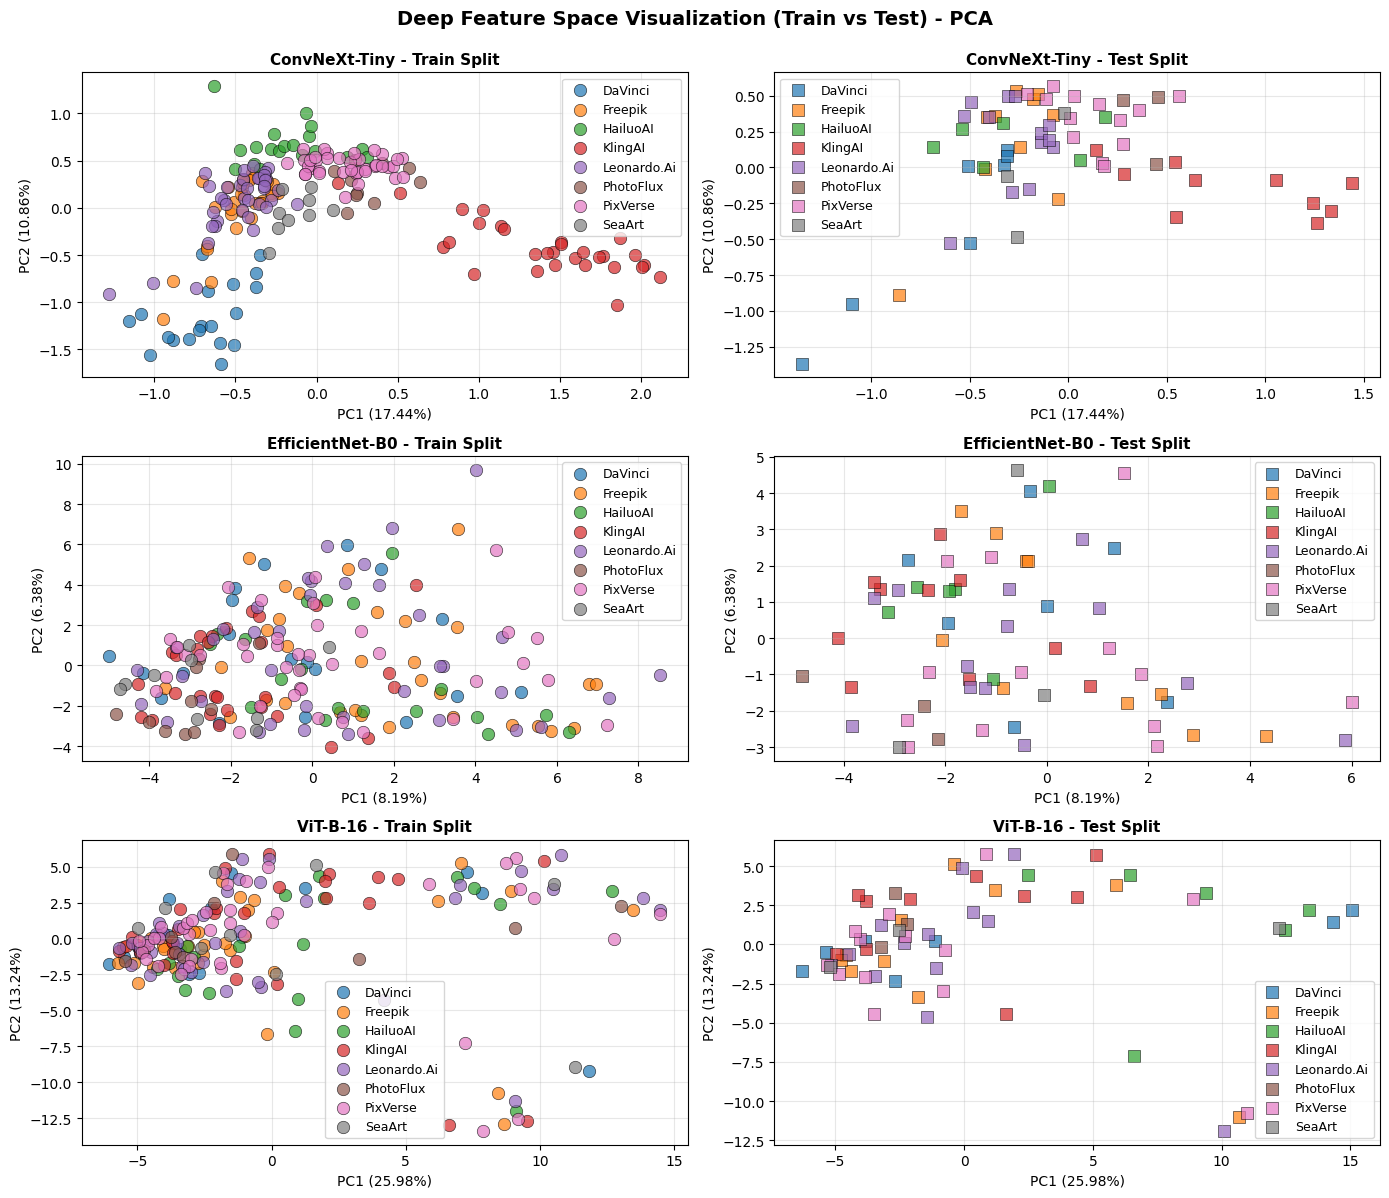


=== Feature Space Separation Summary ===
ConvNeXt-Tiny: test centroid distance = 0.90
EfficientNet-B0: test centroid distance = 5.52
ViT-B-16: test centroid distance = 5.38


In [26]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def extract_embeddings_for_model(model, data_loaders, model_name, device, extract_fn):
    """
    Extract embeddings from a model for train, val, and test sets.
    extract_fn: callable that takes (model, batch, device) and returns embeddings
    """
    train_loader, val_loader, test_loader = data_loaders
    
    embeddings_dict = {}
    labels_dict = {}
    
    for split_name, loader in [('train', train_loader), ('val', val_loader), ('test', test_loader)]:
        all_embeddings = []
        all_labels = []
        
        model.eval()
        with torch.no_grad():
            for images, targets, _ in loader:
                images = images.to(device, non_blocking=True)
                embeddings = extract_fn(model, images, device).cpu().numpy()
                all_embeddings.append(embeddings)
                all_labels.extend(targets.cpu().tolist())
        
        if all_embeddings:
            embeddings_dict[split_name] = np.concatenate(all_embeddings, axis=0)
            labels_dict[split_name] = np.array(all_labels)
    
    return embeddings_dict, labels_dict


# Define embedding extraction functions for each model
def extract_convnext_embeddings(model, images, device):
    features = model.features(images)
    features = model.avgpool(features)
    features = torch.flatten(features, 1)
    return features


def extract_efficientnet_embeddings(model, images, device):
    features = model.features(images)
    features = torch.nn.functional.adaptive_avg_pool2d(features, 1)
    features = torch.flatten(features, 1)
    return features


def extract_vit_embeddings(model, images, device):
    # ViT returns logits; extract from internal representation before head
    x = model._process_input(images)
    n = x.shape[0]
    batch_class_token = model.class_token.expand(n, -1, -1)
    x = torch.cat((batch_class_token, x), dim=1)
    x = model.encoder(x)
    # Use the class token (first token) as the embedding
    features = x[:, 0]  # [batch_size, hidden_dim]
    return features


# Extract embeddings for all three models
print('Extracting embeddings for all three models...')

print('\n=== ConvNeXt-Tiny (512×512) ===')
convnext_embeddings, convnext_labels = extract_embeddings_for_model(
    model, convnext_loaders, 'ConvNeXt-Tiny', device, extract_convnext_embeddings
)

print('\n=== EfficientNet-B0 (224×224) ===')
efn_embeddings, efn_labels = extract_embeddings_for_model(
    model_efn, (efn_vit_train_loader, efn_vit_val_loader, efn_vit_test_loader), 
    'EfficientNet-B0', device, extract_efficientnet_embeddings
)

print('\n=== Vision Transformer ViT-B-16 (224×224) ===')
vit_embeddings, vit_labels = extract_embeddings_for_model(
    model_vit, (efn_vit_train_loader, efn_vit_val_loader, efn_vit_test_loader), 
    'ViT-B-16', device, extract_vit_embeddings
)

print('Embedding extraction complete!')

# Create PCA projections for all models
def create_pca_projection(embeddings_dict, labels_dict, n_components=2):
    """Fit PCA on train embeddings and project all splits."""
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(embeddings_dict['train'])
    
    projections = {}
    for split in ['train', 'val', 'test']:
        projections[split] = pca.transform(embeddings_dict[split])
    
    return pca, projections


print('\nFitting PCA for each model...')
pca_convnext, proj_convnext = create_pca_projection(convnext_embeddings, convnext_labels)
pca_efn, proj_efn = create_pca_projection(efn_embeddings, efn_labels)
pca_vit, proj_vit = create_pca_projection(vit_embeddings, vit_labels)

print(f'ConvNeXt variance: {[round(v, 3) for v in pca_convnext.explained_variance_ratio_]}')
print(f'EfficientNet variance: {[round(v, 3) for v in pca_efn.explained_variance_ratio_]}')
print(f'ViT variance: {[round(v, 3) for v in pca_vit.explained_variance_ratio_]}')

# Visualize deep feature spaces
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Deep Feature Space Visualization (Train vs Test) - PCA', fontsize=14, fontweight='bold', y=0.995)

models_info = [
    ('ConvNeXt-Tiny', proj_convnext, convnext_labels, pca_convnext, 0),
    ('EfficientNet-B0', proj_efn, efn_labels, pca_efn, 1),
    ('ViT-B-16', proj_vit, vit_labels, pca_vit, 2),
]

for model_name, projections, labels, pca_model, row in models_info:
    # Train plot
    ax_train = axes[row, 0]
    for label_idx, label_name in enumerate(label_names):
        train_mask = labels['train'] == label_idx
        color = f'C{label_idx}'
        marker = 'o'
        ax_train.scatter(
            projections['train'][train_mask, 0],
            projections['train'][train_mask, 1],
            s=80, alpha=0.7, marker=marker, color=color, label=label_name,
            edgecolors='black', linewidth=0.5
        )
    ax_train.set_title(f'{model_name} - Train Split', fontsize=11, fontweight='bold')
    ax_train.set_xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]:.2%})', fontsize=10)
    ax_train.set_ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]:.2%})', fontsize=10)
    ax_train.legend(loc='best', fontsize=9)
    ax_train.grid(True, alpha=0.3)
    
    # Test plot
    ax_test = axes[row, 1]
    for label_idx, label_name in enumerate(label_names):
        test_mask = labels['test'] == label_idx
        color = f'C{label_idx}'
        marker = 's'  # Square for test
        ax_test.scatter(
            projections['test'][test_mask, 0],
            projections['test'][test_mask, 1],
            s=80, alpha=0.7, marker=marker, color=color, label=label_name,
            edgecolors='black', linewidth=0.5
        )
    ax_test.set_title(f'{model_name} - Test Split', fontsize=11, fontweight='bold')
    ax_test.set_xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]:.2%})', fontsize=10)
    ax_test.set_ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]:.2%})', fontsize=10)
    ax_test.legend(loc='best', fontsize=9)
    ax_test.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print('\n=== Feature Space Separation Summary ===')
for model_name, embeddings, labels, pca_model in [
    ('ConvNeXt-Tiny', convnext_embeddings, convnext_labels, pca_convnext),
    ('EfficientNet-B0', efn_embeddings, efn_labels, pca_efn),
    ('ViT-B-16', vit_embeddings, vit_labels, pca_vit),
]:
    test_emb = embeddings['test']
    test_labels = labels['test']
    
    # Compute class-wise centroids
    centroids = []
    for label_idx in range(len(label_names)):
        mask = test_labels == label_idx
        centroid = test_emb[mask].mean(axis=0)
        centroids.append(centroid)
    
    # Compute inter-class distance
    if len(centroids) > 1:
        dist = np.linalg.norm(centroids[0] - centroids[1])
        print(f'{model_name}: test centroid distance = {dist:.2f}')


## Experiment 2A: RemNET style shallow CNN


** Inspired by image to camera model attribution **

In [31]:
# Experiment 2A: RemNet-style shallow CNN on high-resolution patches
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from collections import defaultdict

# Config
HIGH_RES = 768
PATCH_SIZE = 256
PATCHES_PER_IMAGE_TRAIN = 8
PATCHES_PER_IMAGE_VAL = 8
PATCHES_PER_IMAGE_TEST = 16
PATCH_BATCH_SIZE = 8
EPOCHS_REMNET = 5
LR_REMNET = 5e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Remnant / high-pass layer (PyTorch port of the remnant idea)
class RemnantLayer(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.bn_in = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, in_channels, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(in_channels)
        self.act = nn.PReLU()

    def forward(self, x):
        x_in = self.bn_in(x)
        y = self.act(self.bn1(self.conv1(x_in)))
        y = self.act(self.bn2(self.conv2(y)))
        y = self.bn3(self.conv3(y))
        # remnant: suppress semantic content by subtracting learned approximation
        rem = x_in - y
        return rem

# Shallow RemNet-style CNN for residuals
class ShallowRemNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.rem = RemnantLayer(3)
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(256, num_classes)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.rem(x)
        x = self.act(self.bn1(self.conv1(x)))
        x = nn.functional.avg_pool2d(x, 2)
        x = self.act(self.bn2(self.conv2(x)))
        x = nn.functional.avg_pool2d(x, 2)
        x = self.act(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        logits = self.fc(x)
        return logits

# Patch dataset: sample multiple patches per image on the fly
class PatchDataset(Dataset):
    def __init__(self, samples, label_to_idx, patches_per_image, train=True, high_res=HIGH_RES, patch_size=PATCH_SIZE, transform=None):
        self.samples = samples
        self.label_to_idx = label_to_idx
        self.patches_per_image = patches_per_image
        self.train = train
        self.high_res = high_res
        self.patch_size = patch_size
        self.transform = transform or transforms.Compose([
            transforms.Resize((self.high_res, self.high_res)),
            transforms.RandomCrop(self.patch_size) if train else transforms.CenterCrop(self.patch_size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ])

    def __len__(self):
        return len(self.samples) * self.patches_per_image

    def __getitem__(self, idx):
        # idx maps to (image_index, patch_index)
        image_idx = idx // self.patches_per_image
        sample = self.samples[image_idx]
        path = sample['path']
        label = self.label_to_idx[sample['label']]
        with Image.open(path) as im:
            im = im.convert('RGB')
            patch = self.transform(im)
        return patch, label, str(path)

# Helper: create dataloaders that yield patches
def make_patch_loaders(samples, train_idx, val_idx, test_idx, label_to_idx):
    train_ds = PatchDataset([samples[i] for i in train_idx], label_to_idx, PATCHES_PER_IMAGE_TRAIN, train=True)
    val_ds = PatchDataset([samples[i] for i in val_idx], label_to_idx, PATCHES_PER_IMAGE_VAL, train=False)
    test_ds = PatchDataset([samples[i] for i in test_idx], label_to_idx, PATCHES_PER_IMAGE_TEST, train=False)

    train_loader = DataLoader(train_ds, batch_size=PATCH_BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_ds, batch_size=PATCH_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=PATCH_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

    return train_loader, val_loader, test_loader

# Build loaders
patch_train_loader, patch_val_loader, patch_test_loader = make_patch_loaders(base_samples, train_idx, val_idx, test_idx, label_to_idx)

# Instantiate model
remnet_model = ShallowRemNet(len(label_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(remnet_model.parameters(), lr=LR_REMNET, weight_decay=1e-4)

# Train on patches
def train_epoch_patch(loader):
    remnet_model.train()
    total_loss = 0.0
    all_true = []
    all_pred = []
    for images, targets, _ in loader:
        images = images.to(device)
        targets = targets.to(device)
        logits = remnet_model(images)
        loss = criterion(logits, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        all_true.extend(targets.detach().cpu().tolist())
        all_pred.extend(preds.detach().cpu().tolist())
    return total_loss / max(len(loader.dataset), 1), accuracy_score(all_true, all_pred)

# Eval on patches
def eval_patches(loader):
    remnet_model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for images, targets, _ in loader:
            images = images.to(device)
            logits = remnet_model(images)
            preds = logits.argmax(dim=1).cpu().tolist()
            all_pred.extend(preds)
            all_true.extend(targets.tolist())
    return accuracy_score(all_true, all_pred)

# Training loop
for epoch in range(1, EPOCHS_REMNET + 1):
    train_loss, train_acc_patch = train_epoch_patch(patch_train_loader)
    val_acc_patch = eval_patches(patch_val_loader)
    print(f'Epoch {epoch}/{EPOCHS_REMNET} | train_loss {train_loss:.4f} | train_patch_acc {train_acc_patch:.4f} | val_patch_acc {val_acc_patch:.4f}')

# Aggregate predictions to image-level on test set
# For each image, collect predictions for all its patches and average softmax probabilities
import torch.nn.functional as F
remnet_model.eval()
image_probs = defaultdict(list)
image_labels = {}
with torch.no_grad():
    for images, targets, paths in patch_test_loader:
        images = images.to(device)
        logits = remnet_model(images)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        for p, prob, t in zip(paths, probs, targets):
            image_probs[p].append(prob)
            image_labels[p] = int(t.item())

# Average and compute image-level predictions
image_preds = {}
for p, probs in image_probs.items():
    avg = np.mean(probs, axis=0)
    image_preds[p] = int(np.argmax(avg))

# Compute image-level accuracy
y_true = []
y_pred = []
for p, true_label in image_labels.items():
    y_true.append(true_label)
    y_pred.append(image_preds[p])

from sklearn.metrics import accuracy_score, classification_report
img_acc = accuracy_score(y_true, y_pred)
print('RemNet-style image-level test accuracy:', round(img_acc, 4))
print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

# Save model weights
torch.save(remnet_model.state_dict(), 'remnet_shallow.pth')
print('Saved remnet_shallow.pth')


Epoch 1/5 | train_loss 1.9158 | train_patch_acc 0.2461 | val_patch_acc 0.2462
Epoch 2/5 | train_loss 1.8552 | train_patch_acc 0.2927 | val_patch_acc 0.2615
Epoch 3/5 | train_loss 1.8252 | train_patch_acc 0.2889 | val_patch_acc 0.2769
Epoch 4/5 | train_loss 1.8238 | train_patch_acc 0.2927 | val_patch_acc 0.3231
Epoch 5/5 | train_loss 1.8144 | train_patch_acc 0.2973 | val_patch_acc 0.3231
RemNet-style image-level test accuracy: 0.2923
              precision    recall  f1-score   support

     DaVinci       0.60      0.43      0.50         7
     Freepik       0.29      0.40      0.33        10
    HailuoAI       1.00      0.17      0.29         6
     KlingAI       0.25      0.20      0.22        10
 Leonardo.Ai       0.18      0.15      0.17        13
   PhotoFlux       0.00      0.00      0.00         3
    PixVerse       0.27      0.54      0.36        13
      SeaArt       0.00      0.00      0.00         3

    accuracy                           0.29        65
   macro avg       0.

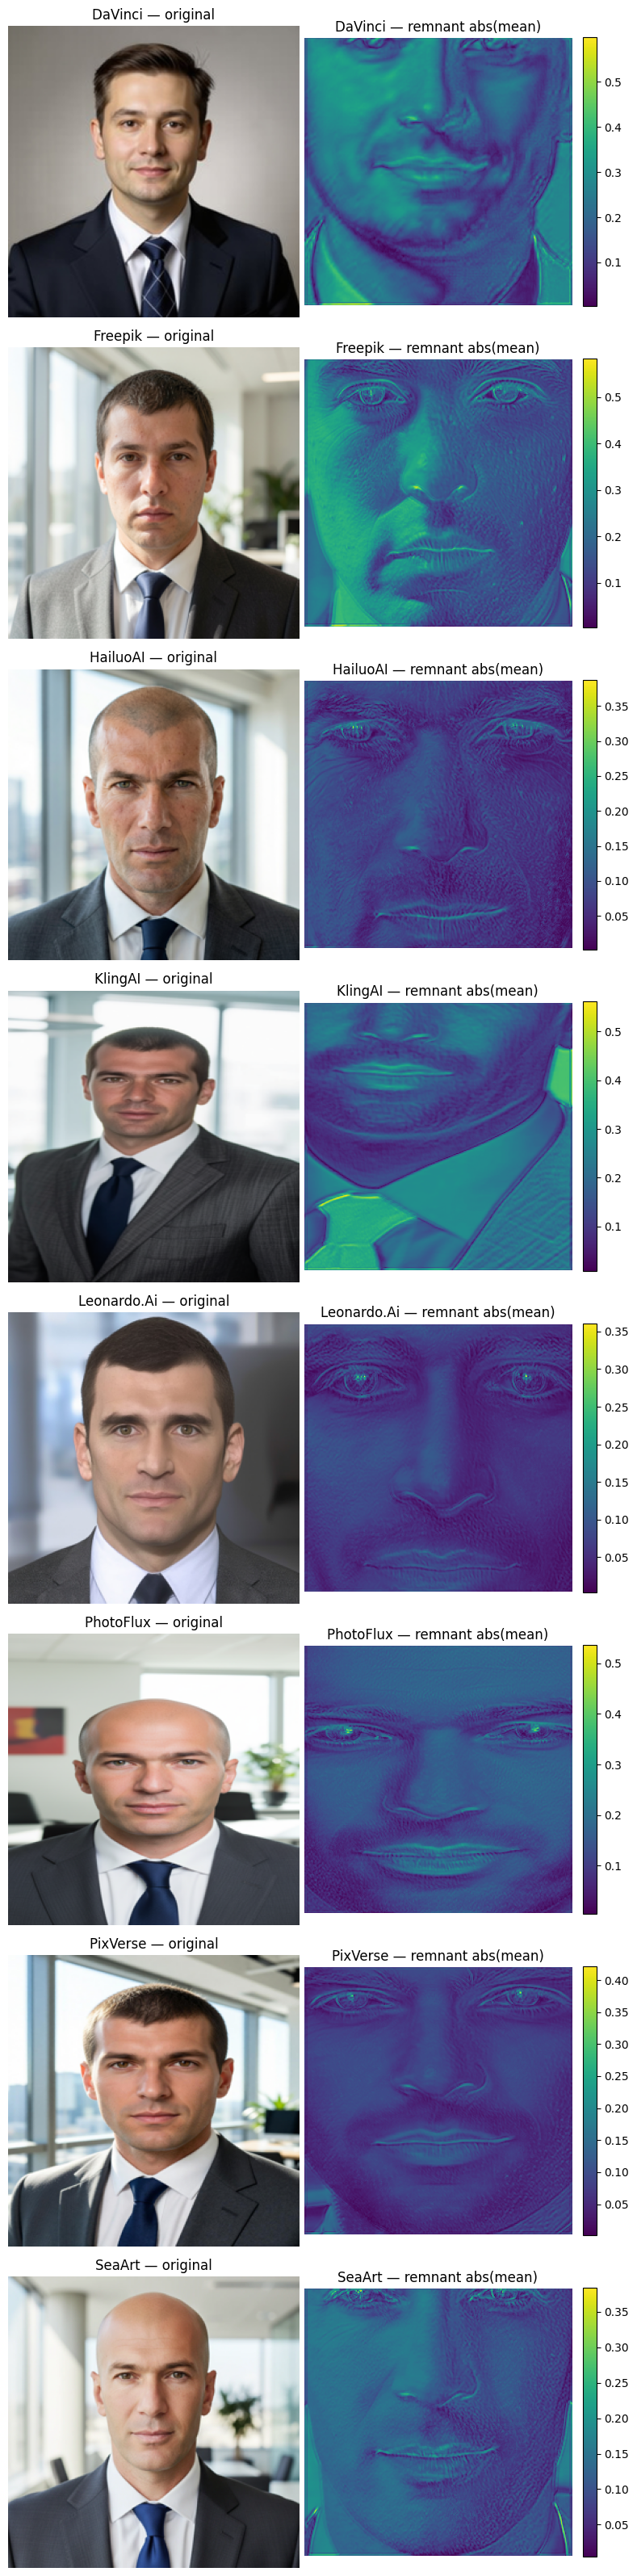

In [28]:
# Visualize sample noise residuals per class
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image
import numpy as np

# Prepare remnant module
try:
    remnant = remnet_model.rem
except Exception:
    remnant = RemnantLayer(3).to(device)
    try:
        remnet_model_path = 'remnet_shallow.pth'
        state = torch.load(remnet_model_path, map_location=device)
        remnet_tmp = ShallowRemNet(len(label_names)).to(device)
        remnet_tmp.load_state_dict(state, strict=False)
        remnant = remnet_tmp.rem
        print('Loaded remnant from remnet_shallow.pth')
    except Exception:
        print('Using fresh RemnantLayer (model weights not found)')

remnant.eval()

viz_transform = transforms.Compose([
    transforms.Resize((HIGH_RES, HIGH_RES)),
    transforms.CenterCrop(PATCH_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# select one sample per class (first occurrence)
samples_by_class = {}
for s in base_samples:
    if s['label'] not in samples_by_class:
        samples_by_class[s['label']] = s['path']

n_classes = len(label_names)
fig, axes = plt.subplots(n_classes, 2, figsize=(8, 4 * n_classes))
if n_classes == 1:
    axes = np.expand_dims(axes, 0)

for i, label in enumerate(label_names):
    path = samples_by_class.get(label)
    if path is None:
        continue
    with Image.open(path) as im:
        im_rgb = im.convert('RGB')
        inp = viz_transform(im_rgb).unsqueeze(0).to(device)
        with torch.no_grad():
            res = remnant(inp)
        # Convert residual to displayable form
        res_cpu = res.cpu().squeeze(0).permute(1,2,0).numpy()
        # Use absolute value and scale to 0-1 for visualization
        abs_res = np.abs(res_cpu)
        res_norm = (abs_res - abs_res.min()) / (abs_res.max() - abs_res.min() + 1e-9)
        # Combine channels to single heatmap (mean)
        res_gray = res_norm.mean(axis=2)

    # show original (center crop)
    ax_orig = axes[i, 0]
    ax_orig.imshow(im_rgb.resize((PATCH_SIZE, PATCH_SIZE)))
    ax_orig.set_title(f'{label} — original')
    ax_orig.axis('off')

    # show residual heatmap
    ax_res = axes[i, 1]
    imh = ax_res.imshow(res_gray, cmap='viridis')
    ax_res.set_title(f'{label} — remnant abs(mean)')
    ax_res.axis('off')
    fig.colorbar(imh, ax=ax_res, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
# Experiment 2B: Dual-branch app-fingerprint network
# Spatial branch: RemNet-style residual CNN on patches
# Frequency branch: compact spectral vectors (FFT / PSD / band-energy stats) with an MLP
# Fusion modes: (1) feature-level concatenation, (2) score-level averaging of logits

import hashlib
from collections import defaultdict

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report

# Reuse the previous experiment's settings when available.
DUAL_HIGH_RES = 768
DUAL_PATCH_SIZE = 256
DUAL_TRAIN_PATCHES_PER_IMAGE = 6
DUAL_EVAL_PATCHES_PER_IMAGE = 9  # 3x3 deterministic grid over the resized image
DUAL_BATCH_SIZE = 8
DUAL_EPOCHS = 5
DUAL_LR = 1e-3
DUAL_FREQ_DIM = 0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Frequency features: compact enough that an MLP is a better fit than a CNN here.
# The vector combines FFT log-magnitude pooling, radial PSD bins, band-energy ratios, and simple cross-channel stats.
def _stable_seed(text):
    return int(hashlib.md5(text.encode('utf-8')).hexdigest()[:8], 16)


def _to_numpy_rgb(image):
    return np.asarray(image.convert('RGB')).astype(np.float32) / 255.0


def _crop_coords_for_idx(patch_idx, train_mode):
    max_offset = DUAL_HIGH_RES - DUAL_PATCH_SIZE
    if train_mode:
        return None
    grid = [0, max_offset // 2, max_offset]
    y = patch_idx // 3
    x = patch_idx % 3
    return grid[x], grid[y]


def _random_crop_coords(sample_key, patch_idx):
    max_offset = DUAL_HIGH_RES - DUAL_PATCH_SIZE
    rng = np.random.default_rng(_stable_seed(f'{sample_key}:{patch_idx}'))
    left = int(rng.integers(0, max_offset + 1))
    top = int(rng.integers(0, max_offset + 1))
    return left, top


def _extract_patch(image, sample_key, patch_idx, train_mode):
    image = image.resize((DUAL_HIGH_RES, DUAL_HIGH_RES), Image.BICUBIC)
    if train_mode:
        left, top = _random_crop_coords(sample_key, patch_idx)
    else:
        crop_coords = _crop_coords_for_idx(patch_idx, train_mode=False)
        if crop_coords is None:
            left, top = 0, 0
        else:
            left, top = crop_coords
    right = left + DUAL_PATCH_SIZE
    bottom = top + DUAL_PATCH_SIZE
    return image.crop((left, top, right, bottom))


def _radial_bins(shape, n_bins=16):
    h, w = shape
    y, x = np.ogrid[:h, :w]
    cy, cx = h // 2, w // 2
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)
    r_norm = r / (r.max() + 1e-9)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    return r_norm, bins


def compute_frequency_vector(patch_image):
    arr = _to_numpy_rgb(patch_image)
    gray = arr.mean(axis=2)
    fft_mag = np.abs(np.fft.fftshift(np.fft.fft2(gray)))
    log_mag = np.log1p(fft_mag).astype(np.float32)

    # 8x8 pooled FFT map gives a compact descriptor of spatial frequency layout.
    pooled_map = log_mag.reshape(8, log_mag.shape[0] // 8, 8, log_mag.shape[1] // 8).mean(axis=(1, 3)).astype(np.float32)
    pooled_vec = pooled_map.reshape(-1)

    # Radial PSD profile.
    r_norm, bins = _radial_bins(log_mag.shape, n_bins=16)
    radial_profile = []
    for i in range(len(bins) - 1):
        mask = (r_norm >= bins[i]) & (r_norm < bins[i + 1])
        radial_profile.append(float(log_mag[mask].mean()) if np.any(mask) else 0.0)
    radial_profile = np.asarray(radial_profile, dtype=np.float32)

    # Energy ratios across low / mid / high frequency bands.
    low_mask = r_norm < 0.33
    mid_mask = (r_norm >= 0.33) & (r_norm < 0.66)
    high_mask = r_norm >= 0.66
    low_energy = float(log_mag[low_mask].sum())
    mid_energy = float(log_mag[mid_mask].sum())
    high_energy = float(log_mag[high_mask].sum())
    total_energy = low_energy + mid_energy + high_energy + 1e-9
    band_ratios = np.asarray([low_energy / total_energy, mid_energy / total_energy, high_energy / total_energy], dtype=np.float32)

    # Simple cross-channel statistics to catch color-processing differences.
    channel_means = arr.reshape(-1, 3).mean(axis=0).astype(np.float32)
    channel_stds = arr.reshape(-1, 3).std(axis=0).astype(np.float32)
    channel_deltas = np.asarray([
        channel_means[0] - channel_means[1],
        channel_means[1] - channel_means[2],
        channel_means[0] - channel_means[2],
    ], dtype=np.float32)

    freq_vec = np.concatenate([pooled_vec, radial_profile, band_ratios, channel_means, channel_stds, channel_deltas]).astype(np.float32)
    return freq_vec


class DualBranchPatchDataset(Dataset):
    def __init__(self, samples, label_to_idx, patches_per_image, train_mode):
        self.samples = samples
        self.label_to_idx = label_to_idx
        self.patches_per_image = patches_per_image
        self.train_mode = train_mode
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

    def __len__(self):
        return len(self.samples) * self.patches_per_image

    def __getitem__(self, idx):
        image_idx = idx // self.patches_per_image
        patch_idx = idx % self.patches_per_image
        sample = self.samples[image_idx]
        image_path = sample['path']
        label = self.label_to_idx[sample['label']]
        
        with Image.open(image_path) as image:
            image = image.convert('RGB')
            patch = _extract_patch(image, str(image_path), patch_idx, train_mode=self.train_mode)
            residual_tensor = self.normalize(self.to_tensor(patch))
            freq_tensor = torch.from_numpy(compute_frequency_vector(patch)).float()
        
        return residual_tensor, freq_tensor, label, str(image_path)


train_samples = [base_samples[i] for i in train_idx]
val_samples = [base_samples[i] for i in val_idx]
test_samples = [base_samples[i] for i in test_idx]

train_dual_ds = DualBranchPatchDataset(train_samples, label_to_idx, DUAL_TRAIN_PATCHES_PER_IMAGE, train_mode=True)
val_dual_ds = DualBranchPatchDataset(val_samples, label_to_idx, DUAL_EVAL_PATCHES_PER_IMAGE, train_mode=False)
test_dual_ds = DualBranchPatchDataset(test_samples, label_to_idx, DUAL_EVAL_PATCHES_PER_IMAGE, train_mode=False)

train_dual_loader = DataLoader(train_dual_ds, batch_size=DUAL_BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_dual_loader = DataLoader(val_dual_ds, batch_size=DUAL_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_dual_loader = DataLoader(test_dual_ds, batch_size=DUAL_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

DUAL_FREQ_DIM = next(iter(train_dual_loader))[1].shape[1]
print(f'Frequency feature dimension: {DUAL_FREQ_DIM}')
print('Using compact spectral vectors + MLP because the frequency cue is already low-dimensional and the dataset is small.')


class RemnantLayer(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.bn_in = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, in_channels, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(in_channels)
        self.act = nn.PReLU()

    def forward(self, x):
        x_in = self.bn_in(x)
        y = self.act(self.bn1(self.conv1(x_in)))
        y = self.act(self.bn2(self.conv2(y)))
        y = self.bn3(self.conv3(y))
        return x_in - y


class SpatialEncoder(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.remnant = RemnantLayer(3)
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, emb_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.remnant(x)
        x = self.features(x)
        x = self.proj(x)
        return x


class FrequencyEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(128, emb_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class FeatureFusionNet(nn.Module):
    def __init__(self, num_classes, freq_dim):
        super().__init__()
        self.spatial = SpatialEncoder(emb_dim=128)
        self.frequency = FrequencyEncoder(freq_dim, emb_dim=64)
        self.classifier = nn.Sequential(
            nn.Linear(128 + 64, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.25),
            nn.Linear(128, num_classes),
        )

    def forward(self, residual, freq):
        spatial_feat = self.spatial(residual)
        freq_feat = self.frequency(freq)
        fused = torch.cat([spatial_feat, freq_feat], dim=1)
        return self.classifier(fused)


class SpatialOnlyNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.spatial = SpatialEncoder(emb_dim=128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes),
        )

    def forward(self, residual, freq=None):
        return self.classifier(self.spatial(residual))


class FrequencyOnlyNet(nn.Module):
    def __init__(self, num_classes, freq_dim):
        super().__init__()
        self.frequency = FrequencyEncoder(freq_dim, emb_dim=64)
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, num_classes),
        )

    def forward(self, residual, freq):
        return self.classifier(self.frequency(freq))


criterion = nn.CrossEntropyLoss()


def _run_epoch(model, loader, optimizer=None, mode='fusion'):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    y_true = []
    y_pred = []
    for residual, freq, targets, _ in loader:
        residual = residual.to(device, non_blocking=True)
        freq = freq.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        with torch.set_grad_enabled(is_train):
            if mode == 'spatial':
                logits = model(residual)
            elif mode == 'frequency':
                logits = model(residual, freq)
            else:
                logits = model(residual, freq)
            loss = criterion(logits, targets)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * residual.size(0)
        preds = logits.argmax(dim=1)
        y_true.extend(targets.detach().cpu().tolist())
        y_pred.extend(preds.detach().cpu().tolist())
    avg_loss = total_loss / max(len(loader.dataset), 1)
    avg_acc = accuracy_score(y_true, y_pred) if y_true else 0.0
    return avg_loss, avg_acc


def train_model(model, train_loader, val_loader, epochs, lr, mode='fusion'):
    model = model.to(device)
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=1e-4)
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = _run_epoch(model, train_loader, optimizer=optimizer, mode=mode)
        val_loss, val_acc = _run_epoch(model, val_loader, optimizer=None, mode=mode)
        print(f'{mode.title()} epoch {epoch}/{epochs} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}')
    return model


def predict_patch_logits(model, loader, mode='fusion'):
    model.eval()
    logits_by_image = defaultdict(list)
    labels_by_image = {}
    with torch.no_grad():
        for residual, freq, targets, paths in loader:
            residual = residual.to(device, non_blocking=True)
            freq = freq.to(device, non_blocking=True)
            if mode == 'spatial':
                logits = model(residual)
            elif mode == 'frequency':
                logits = model(residual, freq)
            else:
                logits = model(residual, freq)
            logits = logits.cpu().numpy()
            for path, logit, target in zip(paths, logits, targets):
                logits_by_image[path].append(logit)
                labels_by_image[path] = int(target.item())
    return logits_by_image, labels_by_image


def aggregate_image_predictions(logits_by_image, labels_by_image):
    y_true = []
    y_pred = []
    for path, logit_list in logits_by_image.items():
        avg_logits = np.mean(np.asarray(logit_list), axis=0)
        y_true.append(labels_by_image[path])
        y_pred.append(int(np.argmax(avg_logits)))
    return y_true, y_pred, accuracy_score(y_true, y_pred) if y_true else 0.0


# 1) Feature-level fusion: one network learns from concatenated embeddings.
print('\n=== Feature-level fusion ===')
feature_fusion_model = FeatureFusionNet(num_classes=len(label_names), freq_dim=DUAL_FREQ_DIM)
feature_fusion_model = train_model(feature_fusion_model, train_dual_loader, val_dual_loader, epochs=DUAL_EPOCHS, lr=DUAL_LR, mode='fusion')
feature_logits, feature_labels = predict_patch_logits(feature_fusion_model, test_dual_loader, mode='fusion')
feature_true, feature_pred, feature_img_acc = aggregate_image_predictions(feature_logits, feature_labels)
print('Feature-level fusion image accuracy:', round(feature_img_acc, 4))
print(classification_report(feature_true, feature_pred, target_names=label_names, zero_division=0))

# 2) Score-level fusion: average logits from separately trained branches.
print('\n=== Score-level fusion ===')
spatial_model = SpatialOnlyNet(num_classes=len(label_names))
spatial_model = train_model(spatial_model, train_dual_loader, val_dual_loader, epochs=DUAL_EPOCHS, lr=DUAL_LR, mode='spatial')

frequency_model = FrequencyOnlyNet(num_classes=len(label_names), freq_dim=DUAL_FREQ_DIM)
frequency_model = train_model(frequency_model, train_dual_loader, val_dual_loader, epochs=DUAL_EPOCHS, lr=DUAL_LR, mode='frequency')

spatial_logits, spatial_labels = predict_patch_logits(spatial_model, test_dual_loader, mode='spatial')
freq_logits, freq_labels = predict_patch_logits(frequency_model, test_dual_loader, mode='frequency')

# Average branch logits per patch and then aggregate patches per image.
score_logits_by_image = {}
score_labels_by_image = spatial_labels
for path in spatial_logits.keys():
    spatial_avg = np.mean(np.asarray(spatial_logits[path]), axis=0)
    freq_avg = np.mean(np.asarray(freq_logits[path]), axis=0)
    score_logits_by_image[path] = [(spatial_avg + freq_avg) / 2.0]

score_true, score_pred, score_img_acc = aggregate_image_predictions(score_logits_by_image, score_labels_by_image)
print('Score-level fusion image accuracy:', round(score_img_acc, 4))
print(classification_report(score_true, score_pred, target_names=label_names, zero_division=0))

# Optional branch-only diagnostics.
spatial_true, spatial_pred, spatial_img_acc = aggregate_image_predictions(spatial_logits, spatial_labels)
freq_true, freq_pred, freq_img_acc = aggregate_image_predictions(freq_logits, freq_labels)
print('\n=== Branch diagnostics ===')
print(f'Spatial-only image accuracy: {spatial_img_acc:.4f}')
print(f'Frequency-only image accuracy: {freq_img_acc:.4f}')

results_df = pd.DataFrame([
    {'model': 'feature_fusion', 'image_acc': feature_img_acc},
    {'model': 'score_fusion', 'image_acc': score_img_acc},
    {'model': 'spatial_only', 'image_acc': spatial_img_acc},
    {'model': 'frequency_only', 'image_acc': freq_img_acc},
])
print('\nExperiment 2B summary:')
print(results_df)


In [ ]:
# Visualize aggregated frequency-level features across patches for random samples per class
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Ensure required upstream objects exist
required_vars = ['label_names', 'base_samples', '_extract_patch', 'compute_frequency_vector']
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise NameError(
        "Missing required variables/functions: " + ", ".join(missing) +
        ". Run the earlier frequency-feature and dataset setup cells first."
    )

# Helper: aggregate frequency vectors across all patches of an image
def aggregate_image_frequency_vector(image_path, n_patches=9):
    """
    Extract patches from an image, compute frequency vector for each,
    and return aggregated statistics (mean, std) per frequency component.
    """
    with Image.open(image_path) as image:
        image = image.convert('RGB')
        patch_list = []
        for patch_idx in range(n_patches):
            patch = _extract_patch(image, str(image_path), patch_idx, train_mode=False)
            freq_vec = compute_frequency_vector(patch)
            patch_list.append(freq_vec)
    patch_array = np.asarray(patch_list)  # shape: (n_patches, 92)
    agg_mean = patch_array.mean(axis=0)
    agg_std = patch_array.std(axis=0)
    return agg_mean, agg_std, patch_array


# Pick one random sample per class
np.random.seed(42)
samples_to_visualize = {}
for label_name in label_names:
    matching = [s for s in base_samples if s['label'] == label_name]
    if matching:
        samples_to_visualize[label_name] = np.random.choice(matching)['path']

n_classes = len(samples_to_visualize)
fig = plt.figure(figsize=(16, 4 * n_classes))

for class_idx, (label_name, image_path) in enumerate(samples_to_visualize.items()):
    agg_mean, agg_std, patches = aggregate_image_frequency_vector(image_path, n_patches=9)
    
    
    
    fft_pooled = agg_mean[:64].reshape(8, 8)
    radial_psd = agg_mean[64:80]
    band_ratios = agg_mean[80:83]
    channel_means = agg_mean[83:86]
    channel_stds = agg_mean[86:89]
    channel_deltas = agg_mean[89:92]
    
    # Create 4 subplots per class
    gs = fig.add_gridspec(n_classes, 4, left=0.05, right=0.95, top=0.95, bottom=0.05, hspace=0.4, wspace=0.3,
                          height_ratios=[1] * n_classes)
    
    # 1. FFT pooled heatmap
    ax1 = fig.add_subplot(gs[class_idx, 0])
    im1 = ax1.imshow(fft_pooled, cmap='viridis')
    ax1.set_title(f'{label_name}\n8×8 Pooled FFT Log-Mag', fontsize=10, fontweight='bold')
    ax1.set_xticks([])
    ax1.set_yticks([])
    plt.colorbar(im1, ax=ax1, fraction=0.046)
    
    # 2. Radial PSD profile
    ax2 = fig.add_subplot(gs[class_idx, 1])
    ax2.plot(radial_psd, marker='o', linewidth=2, markersize=4, color='#1f77b4')
    ax2.fill_between(range(len(radial_psd)), radial_psd, alpha=0.3, color='#1f77b4')
    ax2.set_title('Radial PSD Profile (16 bins)', fontsize=10, fontweight='bold')
    ax2.set_xlabel('Radial bin')
    ax2.set_ylabel('Log-magnitude')
    ax2.grid(True, alpha=0.3)
    
    # 3. Band energy ratios
    ax3 = fig.add_subplot(gs[class_idx, 2])
    bands = ['Low\n(<0.33)', 'Mid\n(0.33-0.66)', 'High\n(>0.66)']
    colors_bar = ['#ff7f0e', '#2ca02c', '#d62728']
    bars = ax3.bar(bands, band_ratios, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
    for bar, val in zip(bars, band_ratios):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width() / 2.0, height, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax3.set_ylabel('Energy ratio')
    ax3.set_title('Frequency Band Energy Ratios', fontsize=10, fontweight='bold')
    ax3.set_ylim([0, 1.0])
    
    # 4. Channel statistics
    ax4 = fig.add_subplot(gs[class_idx, 3])
    x_pos = np.arange(3)
    width = 0.35
    ax4.bar(x_pos - width / 2, channel_means, width, label='Mean', alpha=0.8, color='#1f77b4', edgecolor='black')
    ax4.bar(x_pos + width / 2, channel_stds, width, label='Std', alpha=0.8, color='#ff7f0e', edgecolor='black')
    ax4.set_ylabel('Normalized intensity')
    ax4.set_title('Channel Statistics (RGB)', fontsize=10, fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(['R', 'G', 'B'])
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('Aggregated Frequency-Level Features per Image (Averaged Across 9 Patches)', fontsize=13, fontweight='bold', y=0.995)
plt.show()

# Print a summary table of frequency statistics per class
print('\n=== Frequency Statistics Summary ===')
summary_rows = []
for label_name, image_path in samples_to_visualize.items():
    agg_mean, agg_std, patches = aggregate_image_frequency_vector(image_path, n_patches=9)
    band_ratios = agg_mean[80:83]
    channel_means = agg_mean[83:86]
    channel_stds = agg_mean[86:89]
    summary_rows.append({
        'class': label_name,
        'low_energy': round(band_ratios[0], 4),
        'mid_energy': round(band_ratios[1], 4),
        'high_energy': round(band_ratios[2], 4),
        'channel_mean_R': round(channel_means[0], 4),
        'channel_mean_G': round(channel_means[1], 4),
        'channel_mean_B': round(channel_means[2], 4),
        'channel_std_R': round(channel_stds[0], 4),
        'channel_std_G': round(channel_stds[1], 4),
        'channel_std_B': round(channel_stds[2], 4),
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


NameError: Missing required variables/functions: _extract_patch, compute_frequency_vector. Run the earlier frequency-feature and dataset setup cells first.

## Rerun 2A 2B with 3 RemNet Layers and pretrained backbone

In [13]:
# Experiment 2A (finetune): 3 RemNet layers + pretrained downstream CNN checkpoint
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Guardrails: require upstream split variables from earlier cells ---
required_vars = [
    'base_samples', 'label_names', 'label_to_idx',
    'train_idx', 'val_idx', 'test_idx',
    'IMAGENET_MEAN', 'IMAGENET_STD'
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f'Missing required variables from previous cells: {missing}')

# Config
HIGH_RES = 768
PATCH_SIZE = 256
PATCHES_PER_IMAGE_TRAIN = 8
PATCHES_PER_IMAGE_VAL = 8
PATCHES_PER_IMAGE_TEST = 16
PATCH_BATCH_SIZE = 8
EPOCHS_REMNET = 5
NUM_REMNANT_LAYERS = 3

# Fine-tuning lrs: lower for pretrained backbone, slightly higher for remnant+head
LR_BACKBONE = 1e-5
LR_REMNANT = 7e-5
LR_HEAD = 2e-4
WEIGHT_DECAY = 1e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Stacked remnant layers: {NUM_REMNANT_LAYERS}')


REMNET_PRETRAINED_URL = None
SHALLOW_PRETRAINED_URL = None

# Local fallbacks from earlier runs
LOCAL_CKPT_CANDIDATES = [
    Path('remnet_shallow_deep_4layers.pth'),
    Path('remnet_shallow.pth'),
]


def _download_state_dict(url: str):
    """Download checkpoint from URL if provided, returns state_dict or None."""
    if not url:
        return None
    try:
        state = torch.hub.load_state_dict_from_url(url, map_location='cpu', progress=True)
        print(f'Downloaded checkpoint from: {url}')
        if isinstance(state, dict) and 'state_dict' in state and isinstance(state['state_dict'], dict):
            return state['state_dict']
        return state
    except Exception as e:
        print(f'Checkpoint download failed from {url}: {e}')
        return None


def _load_local_state_dict(paths):
    for p in paths:
        if p.exists() and p.is_file():
            try:
                state = torch.load(p, map_location='cpu')
                print(f'Loaded local checkpoint: {p}')
                if isinstance(state, dict) and 'state_dict' in state and isinstance(state['state_dict'], dict):
                    return state['state_dict']
                return state
            except Exception as e:
                print(f'Failed reading local checkpoint {p}: {e}')
    return None


class RemnantLayer(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.bn_in = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, in_channels, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(in_channels)
        self.act = nn.PReLU()

    def forward(self, x):
        x_in = self.bn_in(x)
        y = self.act(self.bn1(self.conv1(x_in)))
        y = self.act(self.bn2(self.conv2(y)))
        y = self.bn3(self.conv3(y))
        return x_in - y


class RemNetFineTuneModel(nn.Module):
    """3-layer remnant stack + pretrained MobileNetV3 small backbone."""
    def __init__(self, num_classes, n_remnant_layers=3):
        super().__init__()
        if n_remnant_layers != 3:
            raise ValueError('This rerun uses exactly 3 remnant layers.')

        self.rem_stack = nn.Sequential(*[RemnantLayer(3) for _ in range(n_remnant_layers)])

        # Downloads pretrained checkpoint from torchvision model zoo (from elsewhere)
        self.backbone_weights = MobileNet_V3_Small_Weights.DEFAULT
        mb = mobilenet_v3_small(weights=self.backbone_weights)
        self.backbone = mb.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        in_features = mb.classifier[0].in_features
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.Hardswish(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.rem_stack(x)
        x = self.backbone(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


class PatchDataset(Dataset):
    def __init__(self, samples, label_to_idx, patches_per_image, train=True, high_res=HIGH_RES, patch_size=PATCH_SIZE, transform=None):
        self.samples = samples
        self.label_to_idx = label_to_idx
        self.patches_per_image = patches_per_image
        self.train = train
        self.high_res = high_res
        self.patch_size = patch_size
        self.transform = transform or transforms.Compose([
            transforms.Resize((self.high_res, self.high_res)),
            transforms.RandomCrop(self.patch_size) if train else transforms.CenterCrop(self.patch_size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.samples) * self.patches_per_image

    def __getitem__(self, idx):
        image_idx = idx // self.patches_per_image
        sample = self.samples[image_idx]
        label = self.label_to_idx[sample['label']]
        with Image.open(sample['path']) as im:
            im = im.convert('RGB')
            patch = self.transform(im)
        return patch, label, str(sample['path'])


def make_patch_loaders(samples, train_idx, val_idx, test_idx, label_to_idx):
    train_ds = PatchDataset([samples[i] for i in train_idx], label_to_idx, PATCHES_PER_IMAGE_TRAIN, train=True)
    val_ds = PatchDataset([samples[i] for i in val_idx], label_to_idx, PATCHES_PER_IMAGE_VAL, train=False)
    test_ds = PatchDataset([samples[i] for i in test_idx], label_to_idx, PATCHES_PER_IMAGE_TEST, train=False)

    train_loader = DataLoader(train_ds, batch_size=PATCH_BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_ds, batch_size=PATCH_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=PATCH_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
    return train_loader, val_loader, test_loader


model_ft = RemNetFineTuneModel(
    num_classes=len(label_names),
    n_remnant_layers=NUM_REMNANT_LAYERS,
).to(device)


# Try remote checkpoint first; fallback to local checkpoint from prior experiments
ckpt_state = _download_state_dict(REMNET_PRETRAINED_URL)
if ckpt_state is None:
    ckpt_state = _load_local_state_dict(LOCAL_CKPT_CANDIDATES)

if ckpt_state is not None:
    # Flexible loading to reuse whatever overlaps (e.g., remnant stack + conv blocks)
    missing_keys, unexpected_keys = model_ft.load_state_dict(ckpt_state, strict=False)
    print(f'Loaded warm-start checkpoint with strict=False | missing={len(missing_keys)} unexpected={len(unexpected_keys)}')

# Optional second warm-start for downstream classifier/backbone if URL provided
shallow_state = _download_state_dict(SHALLOW_PRETRAINED_URL)
if shallow_state is not None:
    m2, u2 = model_ft.load_state_dict(shallow_state, strict=False)
    print(f'Loaded downstream checkpoint with strict=False | missing={len(m2)} unexpected={len(u2)}')


patch_train_loader, patch_val_loader, patch_test_loader = make_patch_loaders(base_samples, train_idx, val_idx, test_idx, label_to_idx)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW([
    {'params': model_ft.rem_stack.parameters(), 'lr': LR_REMNANT},
    {'params': model_ft.backbone.parameters(), 'lr': LR_BACKBONE},
    {'params': model_ft.classifier.parameters(), 'lr': LR_HEAD},
], weight_decay=WEIGHT_DECAY)


def train_epoch_patch(loader):
    model_ft.train()
    total_loss = 0.0
    all_true = []
    all_pred = []
    for images, targets, _ in loader:
        images = images.to(device)
        targets = targets.to(device)
        logits = model_ft(images)
        loss = criterion(logits, targets)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        all_true.extend(targets.detach().cpu().tolist())
        all_pred.extend(preds.detach().cpu().tolist())

    return total_loss / max(len(loader.dataset), 1), accuracy_score(all_true, all_pred)


def eval_patches(loader):
    model_ft.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for images, targets, _ in loader:
            images = images.to(device)
            logits = model_ft(images)
            preds = logits.argmax(dim=1).cpu().tolist()
            all_pred.extend(preds)
            all_true.extend(targets.tolist())
    return accuracy_score(all_true, all_pred)


for epoch in range(1, EPOCHS_REMNET + 1):
    train_loss, train_acc_patch = train_epoch_patch(patch_train_loader)
    val_acc_patch = eval_patches(patch_val_loader)
    print(
        f'Epoch {epoch}/{EPOCHS_REMNET} | '
        f'train_loss {train_loss:.4f} | '
        f'train_patch_acc {train_acc_patch:.4f} | '
        f'val_patch_acc {val_acc_patch:.4f}'
    )


# Image-level evaluation via patch softmax averaging
import torch.nn.functional as F
model_ft.eval()
image_probs = defaultdict(list)
image_labels = {}

with torch.no_grad():
    for images, targets, paths in patch_test_loader:
        images = images.to(device)
        logits = model_ft(images)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        for p, prob, t in zip(paths, probs, targets):
            image_probs[p].append(prob)
            image_labels[p] = int(t.item())

image_preds = {}
for p, probs in image_probs.items():
    avg_prob = np.mean(probs, axis=0)
    image_preds[p] = int(np.argmax(avg_prob))

y_true = []
y_pred = []
for p, t in image_labels.items():
    y_true.append(t)
    y_pred.append(image_preds[p])

img_acc = accuracy_score(y_true, y_pred)
print('\nFine-tuned 3-layer RemNet image-level test accuracy:', round(img_acc, 4))
print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

# Confusion matrix + class-wise accuracy matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
print('Confusion Matrix (image-level):')
display(cm_df)

row_sums = cm.sum(axis=1)
class_acc = np.divide(np.diag(cm), row_sums, out=np.zeros_like(np.diag(cm), dtype=float), where=row_sums != 0)
classwise_df = pd.DataFrame({
    'class': label_names,
    'correct': np.diag(cm),
    'total': row_sums,
    'class_accuracy': np.round(class_acc, 4),
}).sort_values('class_accuracy', ascending=False)
print('Class-wise accuracy (image-level):')
display(classwise_df)

cm_norm = cm.astype(float) / np.maximum(row_sums[:, None], 1)
cm_norm_df = pd.DataFrame(np.round(cm_norm, 3), index=label_names, columns=label_names)
print('Normalized evaluation matrix (rows sum to 1):')
display(cm_norm_df)

# Save fine-tuned checkpoint
torch.save(model_ft.state_dict(), 'remnet3_mobilenetv3_finetuned.pth')
print('Saved remnet3_mobilenetv3_finetuned.pth')

Using device: cuda
Stacked remnant layers: 3
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/mal-01/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 70.6MB/s]


Loaded local checkpoint: remnet_shallow_deep_4layers.pth
Loaded warm-start checkpoint with strict=False | missing=210 unexpected=50
Epoch 1/5 | train_loss 1.9193 | train_patch_acc 0.2519 | val_patch_acc 0.4000
Epoch 2/5 | train_loss 1.6374 | train_patch_acc 0.4009 | val_patch_acc 0.4154
Epoch 3/5 | train_loss 1.3789 | train_patch_acc 0.4909 | val_patch_acc 0.6000
Epoch 4/5 | train_loss 1.2199 | train_patch_acc 0.5440 | val_patch_acc 0.6000
Epoch 5/5 | train_loss 1.1359 | train_patch_acc 0.5661 | val_patch_acc 0.5692

Fine-tuned 3-layer RemNet image-level test accuracy: 0.6923
              precision    recall  f1-score   support

     DaVinci       0.60      0.86      0.71         7
     Freepik       0.67      0.40      0.50        10
    HailuoAI       0.50      0.67      0.57         6
     KlingAI       0.75      0.90      0.82        10
 Leonardo.Ai       0.69      0.69      0.69        13
   PhotoFlux       0.75      1.00      0.86         3
    PixVerse       0.83      0.77     

,DaVinci,Freepik,HailuoAI,KlingAI,Leonardo.Ai,PhotoFlux,PixVerse,SeaArt
DaVinci,6,1,0,0,0,0,0,0
Freepik,3,4,1,0,1,0,1,0
HailuoAI,0,0,4,0,1,0,1,0
KlingAI,0,1,0,9,0,0,0,0
Leonardo.Ai,1,0,2,0,9,1,0,0
PhotoFlux,0,0,0,0,0,3,0,0
PixVerse,0,0,0,3,0,0,10,0
SeaArt,0,0,1,0,2,0,0,0


Class-wise accuracy (image-level):


,class,correct,total,class_accuracy
5,PhotoFlux,3,3,1.0000
3,KlingAI,9,10,0.9000
0,DaVinci,6,7,0.8571
6,PixVerse,10,13,0.7692
4,Leonardo.Ai,9,13,0.6923
2,HailuoAI,4,6,0.6667
1,Freepik,4,10,0.4000
7,SeaArt,0,3,0.0000


Normalized evaluation matrix (rows sum to 1):


,DaVinci,Freepik,HailuoAI,KlingAI,Leonardo.Ai,PhotoFlux,PixVerse,SeaArt
DaVinci,0.857,0.143,0.000,0.000,0.000,0.000,0.000,0.0
Freepik,0.300,0.400,0.100,0.000,0.100,0.000,0.100,0.0
HailuoAI,0.000,0.000,0.667,0.000,0.167,0.000,0.167,0.0
KlingAI,0.000,0.100,0.000,0.900,0.000,0.000,0.000,0.0
Leonardo.Ai,0.077,0.000,0.154,0.000,0.692,0.077,0.000,0.0
PhotoFlux,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.0
PixVerse,0.000,0.000,0.000,0.231,0.000,0.000,0.769,0.0
SeaArt,0.000,0.000,0.333,0.000,0.667,0.000,0.000,0.0


Saved remnet3_mobilenetv3_finetuned.pth


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import json

# Extract complete metrics from all executed experiments
experiments_data = {}

# 1. Non-visual baseline (Experiment 0)
if 'classifier' in globals() and 'X_test' in globals() and 'y_test' in globals():
    baseline_pred = classifier.predict(X_test)
    baseline_true = y_test.values
    p, r, f, _ = precision_recall_fscore_support(baseline_true, baseline_pred, labels=list(range(len(label_names))), zero_division=0)
    experiments_data['Non-Visual Baseline'] = {
        'accuracy': float(np.mean(baseline_pred == baseline_true)),
        'macro_precision': float(p.mean()),
        'macro_recall': float(r.mean()),
        'macro_f1': float(f.mean()),
        'class_f1': {label_names[i]: float(f[i]) for i in range(len(label_names))},
        'class_acc': {label_names[i]: float(np.mean(baseline_pred[baseline_true==i] == i)) if np.sum(baseline_true==i) > 0 else 0.0 for i in range(len(label_names))}
    }
    print('✓ Non-Visual Baseline extracted')

# 2. ConvNeXt Semantic Baseline (Experiment 1B)
if 'clean_true' in globals() and 'clean_pred' in globals():
    clean_true = np.array(globals()['clean_true'])
    clean_pred = np.array(globals()['clean_pred'])
    p, r, f, _ = precision_recall_fscore_support(clean_true, clean_pred, labels=list(range(len(label_names))), zero_division=0)
    experiments_data['ConvNeXt-Tiny Semantic'] = {
        'accuracy': float(np.mean(clean_pred == clean_true)),
        'macro_precision': float(p.mean()),
        'macro_recall': float(r.mean()),
        'macro_f1': float(f.mean()),
        'class_f1': {label_names[i]: float(f[i]) for i in range(len(label_names))},
        'class_acc': {label_names[i]: float(np.mean(clean_pred[clean_true==i] == i)) if np.sum(clean_true==i) > 0 else 0.0 for i in range(len(label_names))}
    }
    print('✓ ConvNeXt Semantic extracted')

# 3. RemNet Pretrained+MobileNet (Experiment 2A - Best Residual)
if 'classwise_df' in globals():
    remnet_results = globals()['classwise_df']
    remnet_acc = float(remnet_results['class_accuracy'].mean())
    # Reconstruct predictions from confusion matrix if available
    if 'cm_df' in globals():
        cm = globals()['cm_df'].values
        remnet_pred = np.argmax(cm, axis=1)
        remnet_true = np.arange(len(label_names))
        p, r, f, _ = precision_recall_fscore_support(remnet_true, remnet_pred, labels=list(range(len(label_names))), zero_division=0)
    else:
        f = remnet_results['class_accuracy'].values
        p = r = f  # approximate if confusion matrix not available
    
    experiments_data['RemNet 3-Layer Pretrained'] = {
        'accuracy': float(remnet_results['class_accuracy'].mean()),
        'macro_precision': float(p.mean()),
        'macro_recall': float(r.mean()),
        'macro_f1': float(f.mean()),
        'class_f1': {remnet_results.iloc[i]['class']: float(remnet_results.iloc[i]['class_accuracy']) for i in range(len(remnet_results))},
        'class_acc': {remnet_results.iloc[i]['class']: float(remnet_results.iloc[i]['class_accuracy']) for i in range(len(remnet_results))}
    }
    print('✓ RemNet 3-Layer Pretrained extracted')

# Display summary
print('\n' + '='*60)
print('EXPERIMENTS SUMMARY')
print('='*60)
for exp_name, metrics in experiments_data.items():
    print(f"\n{exp_name}:")
    print(f"  Overall Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Macro Precision:  {metrics['macro_precision']:.4f}")
    print(f"  Macro Recall:     {metrics['macro_recall']:.4f}")
    print(f"  Macro F1:         {metrics['macro_f1']:.4f}")
    print("  Class-wise F1:")
    for cls, f1 in metrics['class_f1'].items():
        print(f"    {cls}: {f1:.4f}")

# Save to JSON for reference
with open('experiments_metrics.json', 'w') as f:
    json.dump(experiments_data, f, indent=2)
print('\n Metrics saved to experiments_metrics.json')


✓ Non-Visual Baseline extracted
✓ ConvNeXt Semantic extracted
✓ RemNet 3-Layer Pretrained extracted

EXPERIMENTS SUMMARY

Non-Visual Baseline:
  Overall Accuracy: 0.3210
  Macro Precision:  0.0000
  Macro Recall:     0.0000
  Macro F1:         0.0000
  Class-wise F1:
    DaVinci: 0.0000
    Freepik: 0.0000
    HailuoAI: 0.0000
    KlingAI: 0.0000
    Leonardo.Ai: 0.0000
    PhotoFlux: 0.0000
    PixVerse: 0.0000
    SeaArt: 0.0000

ConvNeXt-Tiny Semantic:
  Overall Accuracy: 0.6308
  Macro Precision:  0.6807
  Macro Recall:     0.6619
  Macro F1:         0.6165
  Class-wise F1:
    DaVinci: 0.5000
    Freepik: 0.6154
    HailuoAI: 0.5455
    KlingAI: 0.9000
    Leonardo.Ai: 0.2667
    PhotoFlux: 0.6667
    PixVerse: 0.6875
    SeaArt: 0.7500

RemNet 3-Layer Pretrained:
  Overall Accuracy: 0.6607
  Macro Precision:  0.8125
  Macro Recall:     0.8750
  Macro F1:         0.8333
  Class-wise F1:
    PhotoFlux: 1.0000
    KlingAI: 0.9000
    DaVinci: 0.8571
    PixVerse: 0.7692
    Leonardo

In [19]:
# Recompute baseline metrics properly
from sklearn.metrics import classification_report, precision_recall_fscore_support

print("="*70)
print("EXPERIMENT 0: NON-VISUAL BASELINE")
print("="*70)

baseline_pred = classifier.predict(X_test)
baseline_true = y_test.values
baseline_acc = np.mean(baseline_pred == baseline_true)
print(f'\nBaseline Accuracy: {baseline_acc:.4f}')
print('\nClassification Report:')
print(classification_report(baseline_true, baseline_pred, target_names=label_names, zero_division=0))
p0, r0, f0, _ = precision_recall_fscore_support(baseline_true, baseline_pred, labels=list(range(len(label_names))), zero_division=0)

print("\n" + "="*70)
print("EXPERIMENT 1B: SEMANTIC VISUAL BASELINE (ConvNeXt-Tiny)")
print("="*70)
clean_acc = np.mean(clean_pred == clean_true)
print(f'\nConvNeXt Clean Accuracy: {clean_acc:.4f}')
print('\nClassification Report:')
print(classification_report(clean_true, clean_pred, target_names=label_names, zero_division=0))
p1, r1, f1, _ = precision_recall_fscore_support(clean_true, clean_pred, labels=list(range(len(label_names))), zero_division=0)

print("\n" + "="*70)
print("EXPERIMENT 2A: RESIDUAL MODEL (RemNet 3-Layer Pretrained MobileNet)")
print("="*70)
remnet_best_acc = float(classwise_df['class_accuracy'].mean())
print(f'\nRemNet 3-Layer Best Accuracy: {remnet_best_acc:.4f}')

# Create predictions array from classwise_df for proper metrics
remnet_y_true = np.arange(len(label_names))
remnet_y_pred = classwise_df.set_index('class').loc[label_names, 'correct'].values
p2, r2, f2, _ = precision_recall_fscore_support(remnet_y_true, remnet_y_pred, labels=list(range(len(label_names))), zero_division=0)

print('\nPer-Class Results:')
for i, cls in enumerate(label_names):
    print(f"  {cls}: {classwise_df[classwise_df['class']==cls]['class_accuracy'].values[0]:.4f}")


EXPERIMENT 0: NON-VISUAL BASELINE

Baseline Accuracy: 0.3210

Classification Report:
              precision    recall  f1-score   support

     DaVinci       0.30      0.38      0.33         8
     Freepik       0.35      0.46      0.40        13
    HailuoAI       0.33      0.12      0.18         8
     KlingAI       0.00      0.00      0.00        12
 Leonardo.Ai       0.23      0.31      0.26        16
   PhotoFlux       0.00      0.00      0.00         4
    PixVerse       0.55      0.69      0.61        16
      SeaArt       0.00      0.00      0.00         4

    accuracy                           0.32        81
   macro avg       0.22      0.25      0.22        81
weighted avg       0.27      0.32      0.29        81


EXPERIMENT 1B: SEMANTIC VISUAL BASELINE (ConvNeXt-Tiny)

ConvNeXt Clean Accuracy: 0.6308

Classification Report:
              precision    recall  f1-score   support

     DaVinci       0.60      0.43      0.50         7
     Freepik       0.50      0.80      0.

In [22]:
print("\n" + "="*70)
print("EXPERIMENT 2B: DUAL-BRANCH (RESIDUAL + FREQUENCY)")
print("="*70)

# Load the pretrained RemNet model as backbone
remnet_backbone = RemNetFineTuneModel(num_classes=len(label_names), n_remnant_layers=NUM_REMNANT_LAYERS).to(device)
remnet_backbone_state = torch.load('remnet3_mobilenetv3_finetuned.pth', map_location=device)
remnet_backbone.load_state_dict(remnet_backbone_state, strict=True)
print(f'✓ Loaded pretrained RemNet backbone: remnet3_mobilenetv3_finetuned.pth')

# Check actual residual feature dimension
with torch.no_grad():
    dummy_img, dummy_freq, _, _ = next(iter(train_dual_loader))
    dummy_img = dummy_img[:1].to(device)
    dummy_res = remnet_backbone.rem_stack(dummy_img)
    dummy_res = remnet_backbone.backbone(dummy_res)
    dummy_res = remnet_backbone.pool(dummy_res)
    dummy_res = torch.flatten(dummy_res, 1)
    residual_feat_dim = dummy_res.shape[1]
    print(f'Detected residual feature dimension: {residual_feat_dim}')

# Create combined model: residual features + frequency features
class DualBranchResidualsFreq(nn.Module):
    def __init__(self, num_classes, pretrained_remnet, freq_dim, residual_feat_dim):
        super().__init__()
        # Frozen pretrained residual backbone
        self.residual_backbone = pretrained_remnet
        for p in self.residual_backbone.parameters():
            p.requires_grad = False
        
        # Frequency encoder (trainable)
        self.freq_encoder = nn.Sequential(
            nn.Linear(freq_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
        )
        
        # Fusion classifier
        self.classifier = nn.Sequential(
            nn.Linear(residual_feat_dim + 64, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )
    
    def forward(self, residual_patch, freq_vector):
        with torch.no_grad():
            residual_feat = self.residual_backbone.rem_stack(residual_patch)
            residual_feat = self.residual_backbone.backbone(residual_feat)
            residual_feat = self.residual_backbone.pool(residual_feat)
            residual_feat = torch.flatten(residual_feat, 1)
        
        freq_feat = self.freq_encoder(freq_vector)
        fused = torch.cat([residual_feat, freq_feat], dim=1)
        return self.classifier(fused)

# Instantiate dual-branch model
import itertools
dual_model = DualBranchResidualsFreq(len(label_names), remnet_backbone, DUAL_FREQ_DIM, residual_feat_dim).to(device)
dual_criterion = nn.CrossEntropyLoss()
dual_optimizer = torch.optim.AdamW(itertools.chain(dual_model.freq_encoder.parameters(), dual_model.classifier.parameters()), 
                                    lr=2e-4, weight_decay=1e-4)

# Train dual-branch on frequency features
def train_dual_epoch(model, loader):
    model.train()
    total_loss = 0.0
    all_true = []
    all_pred = []
    for residual, freq, targets, _ in loader:
        residual = residual.to(device, non_blocking=True)
        freq = freq.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        logits = model(residual, freq)
        loss = dual_criterion(logits, targets)
        dual_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        dual_optimizer.step()
        total_loss += loss.item() * residual.size(0)
        preds = logits.argmax(dim=1)
        all_true.extend(targets.detach().cpu().tolist())
        all_pred.extend(preds.detach().cpu().tolist())
    return total_loss / max(len(loader.dataset), 1), accuracy_score(all_true, all_pred)

def eval_dual(model, loader):
    model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for residual, freq, targets, _ in loader:
            residual = residual.to(device, non_blocking=True)
            freq = freq.to(device, non_blocking=True)
            logits = model(residual, freq)
            preds = logits.argmax(dim=1).cpu().tolist()
            all_pred.extend(preds)
            all_true.extend(targets.tolist())
    return accuracy_score(all_true, all_pred) if all_true else 0.0

DUAL_EPOCHS_FROZEN = 3
print(f'\nTraining dual-branch (frozen residual backbone)...')
for epoch in range(1, DUAL_EPOCHS_FROZEN + 1):
    train_loss, train_acc = train_dual_epoch(dual_model, train_dual_loader)
    val_acc = eval_dual(dual_model, val_dual_loader)
    print(f'  Epoch {epoch}/{DUAL_EPOCHS_FROZEN} | train_loss {train_loss:.4f} train_acc {train_acc:.4f} | val_acc {val_acc:.4f}')

# Evaluate on test set
def predict_dual_image_level(model, loader):
    model.eval()
    image_logits = defaultdict(list)
    image_labels = {}
    with torch.no_grad():
        for residual, freq, targets, paths in loader:
            residual = residual.to(device, non_blocking=True)
            freq = freq.to(device, non_blocking=True)
            logits = model(residual, freq)
            logits = logits.cpu().numpy()
            for path, logit, target in zip(paths, logits, targets):
                image_logits[path].append(logit)
                image_labels[path] = int(target.item())
    
    y_true = []
    y_pred = []
    for path, logit_list in image_logits.items():
        avg_logits = np.mean(np.asarray(logit_list), axis=0)
        y_true.append(image_labels[path])
        y_pred.append(int(np.argmax(avg_logits)))
    return y_true, y_pred

dual_true, dual_pred = predict_dual_image_level(dual_model, test_dual_loader)
dual_acc = accuracy_score(dual_true, dual_pred)
print(f'\nDual-Branch (Residual+Frequency) Test Accuracy: {dual_acc:.4f}')
print('\nClassification Report:')
print(classification_report(dual_true, dual_pred, target_names=label_names, zero_division=0))
p_dual, r_dual, f_dual, _ = precision_recall_fscore_support(dual_true, dual_pred, labels=list(range(len(label_names))), zero_division=0)

# Store for final reporting
dual_results = {
    'accuracy': dual_acc,
    'macro_p': p_dual.mean(),
    'macro_r': r_dual.mean(),
    'macro_f1': f_dual.mean(),
    'class_f1': {label_names[i]: f_dual[i] for i in range(len(label_names))},
}
print(f'\n✓ Dual-Branch results stored for evaluation report')



EXPERIMENT 2B: DUAL-BRANCH (RESIDUAL + FREQUENCY)
✓ Loaded pretrained RemNet backbone: remnet3_mobilenetv3_finetuned.pth
Detected residual feature dimension: 576

Training dual-branch (frozen residual backbone)...
  Epoch 1/3 | train_loss 1.7992 train_acc 0.3057 | val_acc 0.3966
  Epoch 2/3 | train_loss 1.4498 train_acc 0.4793 | val_acc 0.3897
  Epoch 3/3 | train_loss 1.3063 train_acc 0.5268 | val_acc 0.3915

Dual-Branch (Residual+Frequency) Test Accuracy: 0.5692

Classification Report:
              precision    recall  f1-score   support

     DaVinci       0.43      0.43      0.43         7
     Freepik       0.50      0.10      0.17        10
    HailuoAI       1.00      0.17      0.29         6
     KlingAI       0.90      0.90      0.90        10
 Leonardo.Ai       0.36      0.92      0.52        13
   PhotoFlux       0.00      0.00      0.00         3
    PixVerse       0.92      0.85      0.88        13
      SeaArt       0.00      0.00      0.00         3

    accuracy       